<!--<badge>--><a href="https://colab.research.google.com/github/JoeChen322/Fintech/blob/main/classification_ml_models_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->


# Investment Product Classification

This notebook implements a comprehensive machine learning pipeline to classify clients based on their investment profile and recommend suitable financial products. The first part of this notebook contains similar part from the EDA file for the data cleaning and outlier detection part. The workflow encompasses data cleaning, outlier detection, feature engineering, and model training using multiple classifiers.

## Objective

Build accurate binary classifiers for two investment targets:

- **Income Investment**: Investment in income-generating products
- **Accumulation Investment**: Investment in wealth accumulation/growth products

## Workflow

1. Load and explore client dataset
2. Clean and validate data
3. Detect and analyze outliers
4. Transform highly skewed features (Income, Wealth)
5. Engineer domain-specific features
6. Train and tune multiple classifiers
7. Benchmark and compare models


# 1. Imports & Dependencies


In [1]:
%pip install optuna tabulate lime

In [2]:
from typing import Dict

import gdown
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.ensemble import (
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    KFold,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tabulate import tabulate

%config InlineBackend.figure_format = 'retina'

In [3]:
url = "https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX"
file_path = "Dataset2_Needs.xls"
gdown.download(url, file_path, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX
To: /content/Dataset2_Needs.xls
100%|██████████| 428k/428k [00:00<00:00, 13.1MB/s]


'Dataset2_Needs.xls'

# 2. Configuration & Data Loading


In [4]:
needs_df = pd.read_excel(file_path, sheet_name="Needs")
products_df = pd.read_excel(file_path, sheet_name="Products")

# The metadata retrieved is that relating to the needs_df database
metadata_df = pd.read_excel(file_path, sheet_name="Metadata", nrows=11)

# We delete the first line, which doesn't serve much purpose
metadata_df = metadata_df[metadata_df["Metadata"] != "Clients"]

# We remove any potentially unnecessary spaces at the beginning and end of each column name.
# (An unwanted space was present in "income ")
needs_df.columns = needs_df.columns.str.strip()
products_df.columns = products_df.columns.str.strip()
metadata_df.columns = metadata_df.columns.str.strip()

# List of categorical columns in the dataset:
CATEGORICAL_COLS = ["Gender"]

# List of numeric columns in the dataset:
NUMERIC_COLS = [
    "Age",
    "FamilyMembers",
    "FinancialEducation",
    "RiskPropensity",
    "Income",
    "Wealth",
]

# List of target columns in the dataset:
TARGET_COLS = ["IncomeInvestment", "AccumulationInvestment"]

# Value mapping: introduces dictionaries to convert numeric codes into readable labels
VALUE_MAPS: Dict[str, Dict[int, str]] = {
    "Gender": {0: "Male", 1: "Female"},
    "AccumulationInvestment": {0: "Low propensity", 1: "High propensity"},
    "IncomeInvestment": {0: "Low propensity", 1: "High propensity"},
}


# 3. Feature Engineering


Create domain-specific features including ratios, interactions, and life-stage indicators.


1. **Household-Adjusted Metrics** (Ratios)
   These features normalize raw financial data based on the family structure to better reflect "actual" financial capacity.
   **IncomePerFamilyMember&WealthPerFamilyMember**: Instead of looking at total income, these measure the disposable resources available per person. A high income divided by many members indicates less investment "surplus" than the same income for a single individual.
   **WealthIncomeRatio**: This measures financial stability. A high ratio suggests the household has significant accumulated assets relative to their earnings, often identifying "Wealthy" profiles who might prioritize capital preservation over aggressive growth.
2. **Interaction Features**
   Interactions capture how two variables behave differently when combined, allowing models (especially linear ones) to see non-linear patterns.
   **RiskEducationInteraction**: This represents the "Informed Risk" profile. It distinguishes between someone who takes risks due to lack of knowledge and someone who takes calculated risks based on financial literacy.
   **RiskWealthInteraction**: This captures the "Capacity for Loss." High risk propensity combined with high wealth indicates a client who can afford aggressive investment strategies without jeopardizing their basic needs.
   **AgeRiskInteraction**: This models the "Time Horizon." Younger individuals with high risk tolerance have time to recover from market drops, whereas older individuals with high risk tolerance still face a shorter investment window, changing their optimal portfolio.
3. **Non-linearity and Life-Stage Flags**
   These features help the model understand that human behavior doesn't change linearly as we get older.
   **AgeSquared**: This accounts for the "Life-Cycle Hypothesis." Wealth and investment activity typically follow a U-shaped or parabolic curve—increasing during peak working years and decreasing during retirement.
   **Life-Stage Flags (Age_Under35, 35_54, etc.)**: These transform age into categorical milestones. Instead of treating age as just a number, these flags tell the model: "This person is a 'Young Professional' or a 'Retiree'." Each stage has distinct financial goals (e.g., buying a first home vs. estate planning).


In [5]:
final_X = needs_df.drop(columns=TARGET_COLS + ["ID"])

final_Y = needs_df[TARGET_COLS].copy()

for col in TARGET_COLS:
    final_Y[col] = pd.to_numeric(final_Y[col])


y_income = final_Y["IncomeInvestment"]

y_accum = final_Y["AccumulationInvestment"]

In [6]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Creates engineered features and filters columns based on the apple_feat_eng flag.
    """

    def __init__(self, apple_feat_eng=True):
        self.apple_feat_eng = apple_feat_eng

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()

        # Create engineered features
        has_income = "Income" in X_transformed.columns
        has_wealth = "Wealth" in X_transformed.columns
        has_family = "FamilyMembers" in X_transformed.columns
        has_risk = "RiskPropensity" in X_transformed.columns
        has_edu = "FinancialEducation" in X_transformed.columns
        has_age = "Age" in X_transformed.columns

        if has_income and has_family:
            X_transformed["IncomePerFamilyMember"] = (
                X_transformed["Income"] / X_transformed["FamilyMembers"]
            )
        if has_wealth and has_family:
            X_transformed["WealthPerFamilyMember"] = (
                X_transformed["Wealth"] / X_transformed["FamilyMembers"]
            )
        if has_income and has_wealth:
            X_transformed["WealthIncomeRatio"] = (
                X_transformed["Wealth"] / X_transformed["Income"]
            )

        if has_risk and has_edu:
            X_transformed["RiskEducationInteraction"] = (
                X_transformed["RiskPropensity"] * X_transformed["FinancialEducation"]
            )

        if has_risk:
            wealth_col = (
                "Wealth_log" if "Wealth_log" in X_transformed.columns else "Wealth"
            )
            if wealth_col in X_transformed.columns:
                X_transformed["RiskWealthInteraction"] = (
                    X_transformed["RiskPropensity"] * X_transformed[wealth_col]
                )

        if has_age and has_risk:
            X_transformed["AgeRiskInteraction"] = (
                X_transformed["Age"] * X_transformed["RiskPropensity"]
            )

        if has_age:
            X_transformed["AgeSquared"] = X_transformed["Age"] ** 2
            X_transformed["Age_Under35"] = (X_transformed["Age"] < 35).astype(int)
            X_transformed["Age_35_54"] = (
                (X_transformed["Age"] >= 35) & (X_transformed["Age"] < 55)
            ).astype(int)
            X_transformed["Age_55_69"] = (
                (X_transformed["Age"] >= 55) & (X_transformed["Age"] < 70)
            ).astype(int)
            X_transformed["Age_70plus"] = (X_transformed["Age"] >= 70).astype(int)

        features_base = [
            "Age",
            "Gender",
            "FamilyMembers",
            "FinancialEducation",
            "RiskPropensity",
            "Wealth_log",
            "Income_log",
        ]

        features_engineered = [
            "Age",
            "Gender",
            "FamilyMembers",
            "FinancialEducation",
            "RiskPropensity",
            "IncomePerFamilyMember",
            "WealthPerFamilyMember",
            "WealthIncomeRatio",
            "RiskEducationInteraction",
            "RiskWealthInteraction",
            "AgeRiskInteraction",
            "AgeSquared",
            "Age_Under35",
            "Age_35_54",
            "Age_55_69",
            "Age_70plus",
        ]

        if self.apple_feat_eng:
            cols = [c for c in features_engineered if c in X_transformed.columns]
        else:
            cols = [c for c in features_base if c in X_transformed.columns]

        return X_transformed[cols]

# 4. Model Training & Evaluation Framework


We define helper functions for model training, evaluation, and results visualization.


In [7]:
def split_data(X, y, test_size=0.2, random_state=42):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    return X_train, X_test, y_train, y_test


def train_evaluate_model(X_train, y_train, X_test, y_test, model, k_folds=5):
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    cv_metrics = {"accuracy": [], "precision": [], "recall": [], "f1": []}

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_val_pred = model.predict(X_val_fold)

        cv_metrics["accuracy"].append(accuracy_score(y_val_fold, y_val_pred))
        cv_metrics["precision"].append(precision_score(y_val_fold, y_val_pred))
        cv_metrics["recall"].append(recall_score(y_val_fold, y_val_pred))
        cv_metrics["f1"].append(f1_score(y_val_fold, y_val_pred))

    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)

    return {
        "cv_metrics": {
            metric: {"mean": np.mean(scores), "std": np.std(scores)}
            for metric, scores in cv_metrics.items()
        },
        "test_metrics": {
            "accuracy": accuracy_score(y_test, y_test_pred),
            "precision": precision_score(y_test, y_test_pred),
            "recall": recall_score(y_test, y_test_pred),
            "f1": f1_score(y_test, y_test_pred),
        },
    }


def display_results_table(results_dict, model_name, feature_type):
    cv_data = {
        "Metric": ["Accuracy", "Precision", "Recall", "F1"],
        "CV Mean": [
            results_dict["cv_metrics"]["accuracy"]["mean"],
            results_dict["cv_metrics"]["precision"]["mean"],
            results_dict["cv_metrics"]["recall"]["mean"],
            results_dict["cv_metrics"]["f1"]["mean"],
        ],
        "CV Std": [
            results_dict["cv_metrics"]["accuracy"]["std"],
            results_dict["cv_metrics"]["precision"]["std"],
            results_dict["cv_metrics"]["recall"]["std"],
            results_dict["cv_metrics"]["f1"]["std"],
        ],
        "Test Set": [
            results_dict["test_metrics"]["accuracy"],
            results_dict["test_metrics"]["precision"],
            results_dict["test_metrics"]["recall"],
            results_dict["test_metrics"]["f1"],
        ],
    }

    df = pd.DataFrame(cv_data)
    df = df.round(3)

    print(f"\n{model_name} - {feature_type}")
    print("=" * 60)
    print(tabulate(df, headers="keys", tablefmt="pretty"))


# 5. Model Training & Evaluation

with our personalized features using scikit-learn Pipelines for reproducible and maintainable ML workflows.


Train and optimize multiple classification models using cross-validation.


### 5.1 ML Pipelines Setup

We use scikit-learn Pipelines to encapsulate preprocessing + model training.


In [8]:
class DataTransformer(BaseEstimator, TransformerMixin):
    """
    Cleans data by converting values to numeric and applying log transformations
    to skewed financial variables.
    """

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()

        for col in X_transformed.columns:
            X_transformed[col] = pd.to_numeric(X_transformed[col], errors="coerce")

        # Apply log transformations to Wealth and Income
        cols_to_log = ["Income", "Wealth"]
        for col in cols_to_log:
            if col in X_transformed.columns:
                X_transformed[f"{col}_log"] = np.log1p(X_transformed[col])

        return X_transformed


def create_pipeline(
    classifier, apple_feat_eng=True, feature_selector=None, n_features="auto"
):
    steps = [
        ("transformer", DataTransformer()),
        ("engineer", FeatureEngineer(apple_feat_eng=apple_feat_eng)),
        ("scaler", StandardScaler().set_output(transform="pandas")),
    ]

    if feature_selector == "kbest":
        steps.append(("feature_selector", SelectKBest(f_classif, k=n_features)))
    elif feature_selector == "mutual_info":
        steps.append(
            ("feature_selector", SelectKBest(mutual_info_classif, k=n_features))
        )

    steps.append(("classifier", classifier))

    return Pipeline(steps)


## Ensemble Methods

### Voting Classifier

Combines predictions from multiple independent base learners using a voting strategy:

- **Soft Voting**: Averages predicted probabilities across all classifiers, then assigns the class with the highest average probability
  - Better calibrated predictions
  - Leverages confidence scores from individual models
- **Hard Voting**: Uses majority voting on predicted class labels
  - More robust to individual model errors
  - Simple and interpretable
- **Base Learners**: SVM, XGBoost, and Random Forest
- **Advantage**: Simple and effective ensemble that captures diverse learning patterns

### Stacking Classifier

Uses a meta-learner to optimally combine predictions from multiple base learners:

- **Base Learners**: SVM, XGBoost, K-Nearest Neighbors, and Random Forest
- **Meta-Learner**: Logistic Regression (learns optimal weights for combining base predictions)
- **Cross-Validation**: Uses 5-fold CV on training data to generate meta-features
- **Advantage**: More sophisticated approach that learns how to best combine diverse models


Compare performance across all models and feature sets.


In [9]:
def _cv_summary(estimator, X_train, y_train, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        cv=cv,
        scoring=["accuracy", "precision", "recall", "f1"],
        n_jobs=-1,
        error_score="raise",
    )
    return {
        "CV Accuracy (mean)": float(np.mean(scores["test_accuracy"])),
        "CV Accuracy (std)": float(np.std(scores["test_accuracy"])),
        "CV Precision (mean)": float(np.mean(scores["test_precision"])),
        "CV Precision (std)": float(np.std(scores["test_precision"])),
        "CV Recall (mean)": float(np.mean(scores["test_recall"])),
        "CV Recall (std)": float(np.std(scores["test_recall"])),
        "CV F1 (mean)": float(np.mean(scores["test_f1"])),
        "CV F1 (std)": float(np.std(scores["test_f1"])),
    }


def _test_summary(estimator, X_train, y_train, X_test, y_test):
    est = clone(estimator)
    est.fit(X_train, y_train)
    y_pred = est.predict(X_test)
    return {
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred, zero_division=0),
        "Test Recall": recall_score(y_test, y_pred, zero_division=0),
        "Test F1": f1_score(y_test, y_pred, zero_division=0),
    }

In [10]:
rows = []

feature_sets = [
    ("Base", False),
    ("Engineered", True),
]

for target_name, y in [
    ("Income Investment", y_income),
    ("Accumulation Investment", y_accum),
]:
    for feat_label, apply_transform in feature_sets:
        X_train, X_test, y_train, y_test = split_data(final_X, y)

        # Baseline models using Pipelines for reproducibility
        models = {
            "SVM-baseline": create_pipeline(
                SVC(random_state=42), apple_feat_eng=apply_transform
            ),
            "NaiveBayes-baseline": create_pipeline(
                GaussianNB(), apple_feat_eng=apply_transform
            ),
            "KNN-baseline": create_pipeline(
                KNeighborsClassifier(), apple_feat_eng=apply_transform
            ),
            "RandomForest-baseline": create_pipeline(
                apple_feat_eng=apply_transform,
                classifier=RandomForestClassifier(
                    n_estimators=50,
                    max_depth=10,
                    min_samples_split=20,
                    min_samples_leaf=10,
                    n_jobs=-1,
                    random_state=42,
                ),
            ),
            "XGBoost-baseline": create_pipeline(
                apple_feat_eng=apply_transform,
                classifier=xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
            ),
        }

        # Voting Classifier: Combines predictions from multiple base learners
        # Uses soft voting to average predicted probabilities
        models["Voting (soft)"] = create_pipeline(
            apple_feat_eng=apply_transform,
            classifier=VotingClassifier(
                estimators=[
                    ("xgb", xgb.XGBClassifier(random_state=42)),
                    ("knn", KNeighborsClassifier(n_neighbors=3, n_jobs=-1)),
                    (
                        "rf",
                        RandomForestClassifier(
                            n_estimators=40,
                            max_depth=10,
                            min_samples_split=20,
                            min_samples_leaf=10,
                            n_jobs=-1,
                            random_state=42,
                        ),
                    ),
                ],
                voting="soft",
            ),
        )

        # Hard Voting Classifier: Takes majority vote on class labels
        models["Voting (hard)"] = create_pipeline(
            apple_feat_eng=apply_transform,
            classifier=VotingClassifier(
                estimators=[
                    ("knn", KNeighborsClassifier(n_neighbors=3, n_jobs=-1)),
                    (
                        "rf",
                        RandomForestClassifier(
                            n_estimators=50,
                            max_depth=10,
                            min_samples_split=20,
                            min_samples_leaf=10,
                            n_jobs=-1,
                            random_state=42,
                        ),
                    ),
                ],
                voting="hard",
            ),
        )

        # Stacking Classifier: Uses a meta-learner to combine base learner predictions
        # Meta-learner: Logistic Regression
        stacking_clf = StackingClassifier(
            estimators=[
                ("lgb", LGBMClassifier(random_state=42)),
                ("xgb", xgb.XGBClassifier(random_state=42)),
                ("knn", KNeighborsClassifier(n_neighbors=3, n_jobs=-1)),
                (
                    "rf",
                    RandomForestClassifier(
                        n_estimators=50,
                        max_depth=10,
                        min_samples_split=20,
                        min_samples_leaf=10,
                        n_jobs=-1,
                        random_state=42,
                    ),
                ),
            ],
            final_estimator=LogisticRegression(),
            cv=3,  # Internal cross-validation to train the meta-learner
            stack_method="predict_proba",  # Passes probabilities to the meta-learner
        )
        models["Stacking (LogReg)"] = create_pipeline(
            stacking_clf, apple_feat_eng=apply_transform
        )

        models["LightGBM-baseline"] = create_pipeline(
            apple_feat_eng=apply_transform,
            classifier=LGBMClassifier(
                n_estimators=100,
                learning_rate=0.05,
                num_leaves=31,
                random_state=42,
                importance_type="gain",
                verbosity=-1,
                force_col_wise=True,
            ),
        )

        for model_name, model in models.items():
            base = {
                "Target": target_name,
                "Feature set": feat_label,
                "Model": model_name,
            }
            cv_part = _cv_summary(clone(model), X_train, y_train)
            test_part = _test_summary(model, X_train, y_train, X_test, y_test)
            rows.append({**base, **cv_part, **test_part})


[LightGBM] [Info] Number of positive: 1534, number of negative: 2466
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000430 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1100
[LightGBM] [Info] Number of data points in the train set: 4000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383500 -> initscore=-0.474719
[LightGBM] [Info] Start training from score -0.474719
[LightGBM] [Info] Number of positive: 1022, number of negative: 1644
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000089 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1096
[LightGBM] [Info] Number of data points in the train set: 2666, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383346 -> initscore=-0.475371
[LightGBM]

In [11]:
bench_df = pd.DataFrame(rows)
bench_df = bench_df.sort_values(
    ["Target", "Feature set", "Test F1"], ascending=[True, True, False]
)
display(bench_df.round(4))

,Target,Feature set,Model,CV Accuracy (mean),CV Accuracy (std),CV Precision (mean),CV Precision (std),CV Recall (mean),CV Recall (std),CV F1 (mean),CV F1 (std),Test Accuracy,Test Precision,Test Recall,Test F1
26,Accumulation Investment,Base,LightGBM-baseline,0.8055,0.0093,0.8671,0.0109,0.7336,0.0126,0.7947,0.0103,0.800,0.8380,0.7563,0.7951
25,Accumulation Investment,Base,Stacking (LogReg),0.7962,0.0122,0.8360,0.0104,0.7501,0.0188,0.7907,0.0138,0.789,0.8082,0.7719,0.7896
21,Accumulation Investment,Base,RandomForest-baseline,0.7773,0.0143,0.8117,0.0154,0.7370,0.0150,0.7725,0.0146,0.774,0.7899,0.7622,0.7758
22,Accumulation Investment,Base,XGBoost-baseline,0.7865,0.0137,0.8195,0.0137,0.7492,0.0218,0.7826,0.0154,0.768,0.7827,0.7583,0.7703
23,Accumulation Investment,Base,Voting (soft),0.7790,0.0137,0.8107,0.0108,0.7428,0.0222,0.7752,0.0158,0.757,0.7733,0.7446,0.7587
18,Accumulation Investment,Base,SVM-baseline,0.7545,0.0204,0.7816,0.0196,0.7238,0.0241,0.7516,0.0215,0.747,0.7621,0.7368,0.7493
24,Accumulation Investment,Base,Voting (hard),0.7377,0.0131,0.8502,0.0239,0.5943,0.0129,0.6994,0.0137,0.741,0.8240,0.6296,0.7138
20,Accumulation Investment,Base,KNN-baseline,0.6937,0.0139,0.7088,0.0143,0.6849,0.0165,0.6965,0.0137,0.683,0.6944,0.6823,0.6883
19,Accumulation Investment,Base,NaiveBayes-baseline,0.6115,0.0179,0.6030,0.0174,0.7146,0.0082,0.6539,0.0105,0.601,0.5888,0.7368,0.6545
35,Accumulation Investment,Engineered,LightGBM-baseline,0.8215,0.0035,0.8888,0.0118,0.7457,0.0095,0.8109,0.0036,0.821,0.8662,0.7700,0.8153


We can see that generally, the two models in addition to stacking, that obtain the highest results are Random Forest and LightGBM. Consequently we will optimize both models and apply explainability.


# 6. Optuna Hyperparameter Tuning


## Tuning for Random Forest

Use Optuna to optimize Random Forest hyperparameters with F1 score as the objective metric.


In [12]:
def create_optuna_rf_optimizer(X_train, y_train, n_trials=20, cv_folds=5):
    """
    Create and run an Optuna study to optimize Random Forest hyperparameters.

    Args:
        X_train: Training features
        y_train: Training labels
        n_trials: Number of trials for Optuna to run
        cv_folds: Number of cross-validation folds

    Returns:
        best_params: Dictionary of best hyperparameters
        study: Optuna study object
        best_trial: Best trial object
    """

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 10, 200),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
            "max_features": trial.suggest_categorical(
                "max_features", ["sqrt", "log2", None]
            ),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
            "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
        }

        rf_model = RandomForestClassifier(**params, n_jobs=-1, random_state=42)
        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        precision_scores = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

            rf_model.fit(X_train_fold, y_train_fold)
            y_pred = rf_model.predict(X_val_fold)
            precision_scores.append(
                precision_score(y_val_fold, y_pred, zero_division=0)
            )

        return np.mean(precision_scores)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_trial = study.best_trial
    best_params = best_trial.params

    return best_params, study, best_trial

In [13]:
RF_N_TRIALS = 1
rf_tuning_results = {}

for target_label, y_target in [
    ("Income Investment", y_income),
    ("Accumulation Investment", y_accum),
]:
    print("\n" + "=" * 80)
    print(f"OPTUNA HYPERPARAMETER TUNING FOR RANDOM FOREST - {target_label}")
    print("=" * 80)

    X_train_rf, X_test_rf, y_train_rf, y_test_rf = split_data(final_X, y_target)
    best_params_rf, study_rf, best_trial_rf = create_optuna_rf_optimizer(
        X_train_rf, y_train_rf, n_trials=RF_N_TRIALS, cv_folds=5
    )

    print(f"\nOptimization completed in {len(study_rf.trials)} trials")
    print(f"Best Precision (CV): {best_trial_rf.value:.4f}")
    print("\nBest Hyperparameters:")
    for key, value in best_params_rf.items():
        print(f"  {key}: {value}")

    rf_tuning_results[target_label] = {
        "best_params": best_params_rf,
        "study": study_rf,
        "best_trial": best_trial_rf,
        "X_train": X_train_rf,
        "X_test": X_test_rf,
        "y_train": y_train_rf,
        "y_test": y_test_rf,
    }

# Keep compatibility with downstream cells already using these names
best_params = rf_tuning_results["Income Investment"]["best_params"]
study = rf_tuning_results["Income Investment"]["study"]
best_trial = rf_tuning_results["Income Investment"]["best_trial"]
X_train_eng = rf_tuning_results["Income Investment"]["X_train"]
X_test_eng = rf_tuning_results["Income Investment"]["X_test"]
y_train_income = rf_tuning_results["Income Investment"]["y_train"]
y_test_income = rf_tuning_results["Income Investment"]["y_test"]

best_params_accum = rf_tuning_results["Accumulation Investment"]["best_params"]
study_accum = rf_tuning_results["Accumulation Investment"]["study"]
best_trial_accum = rf_tuning_results["Accumulation Investment"]["best_trial"]

[I 2026-04-18 22:44:44,740] A new study created in memory with name: no-name-7fa0852d-e3eb-4625-9f90-1d14acc9e57c



OPTUNA HYPERPARAMETER TUNING FOR RANDOM FOREST - Income Investment


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-04-18 22:44:47,189] A new study created in memory with name: no-name-5c0d64fe-18a6-4f63-a70f-40e473b5f03d


[I 2026-04-18 22:44:47,172] Trial 0 finished with value: 0.8456260571361472 and parameters: {'n_estimators': 81, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 0 with value: 0.8456260571361472.

Optimization completed in 1 trials
Best Precision (CV): 0.8456

Best Hyperparameters:
  n_estimators: 81
  max_depth: 10
  min_samples_split: 15
  min_samples_leaf: 6
  max_features: sqrt
  bootstrap: True
  criterion: gini

OPTUNA HYPERPARAMETER TUNING FOR RANDOM FOREST - Accumulation Investment


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-04-18 22:44:49,603] Trial 0 finished with value: 0.818967266008847 and parameters: {'n_estimators': 81, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True, 'criterion': 'gini'}. Best is trial 0 with value: 0.818967266008847.

Optimization completed in 1 trials
Best Precision (CV): 0.8190

Best Hyperparameters:
  n_estimators: 81
  max_depth: 10
  min_samples_split: 15
  min_samples_leaf: 6
  max_features: sqrt
  bootstrap: True
  criterion: gini


In [14]:
# Compare baseline vs optimized Random Forest performance
print("\n" + "=" * 80)
print("PERFORMANCE COMPARISON: BASELINE vs OPTUNA-OPTIMIZED")
print("=" * 80)

# Train baseline model (parameters from earlier)
baseline_rf = create_pipeline(
    RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42,
    ),
    apple_feat_eng=True,
)

# Train optimized model with best parameters
optimized_rf = create_pipeline(
    RandomForestClassifier(**best_params, n_jobs=-1, random_state=42),
    apple_feat_eng=True,
)

# Train both models
baseline_rf.fit(X_train_eng, y_train_income)
optimized_rf.fit(X_train_eng, y_train_income)


# Get predictions and metrics for both
def get_metrics(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "Train Accuracy": accuracy_score(y_train, y_train_pred),
        "Test Accuracy": accuracy_score(y_test, y_test_pred),
        "Train Precision": precision_score(y_train, y_train_pred),
        "Test Precision": precision_score(y_test, y_test_pred),
        "Train Recall": recall_score(y_train, y_train_pred),
        "Test Recall": recall_score(y_test, y_test_pred),
        "Train F1": f1_score(y_train, y_train_pred),
        "Test F1": f1_score(y_test, y_test_pred),
    }


baseline_metrics = get_metrics(
    baseline_rf, X_train_eng, y_train_income, X_test_eng, y_test_income
)
optimized_metrics = get_metrics(
    optimized_rf, X_train_eng, y_train_income, X_test_eng, y_test_income
)

# Create comparison table
comparison_df = pd.DataFrame(
    {
        "Metric": list(baseline_metrics.keys()),
        "Baseline": list(baseline_metrics.values()),
        "Optuna-Optimized": list(optimized_metrics.values()),
    }
)

comparison_df["Improvement"] = (
    comparison_df["Optuna-Optimized"] - comparison_df["Baseline"]
)
comparison_df["Improvement %"] = (
    comparison_df["Improvement"] / comparison_df["Baseline"] * 100
).round(2)

print(
    "\n"
    + tabulate(
        comparison_df.round(4), headers="keys", tablefmt="pretty", showindex=False
    )
)


PERFORMANCE COMPARISON: BASELINE vs OPTUNA-OPTIMIZED

+-----------------+----------+------------------+-------------+---------------+
|     Metric      | Baseline | Optuna-Optimized | Improvement | Improvement % |
+-----------------+----------+------------------+-------------+---------------+
| Train Accuracy  |  0.8275  |      0.8358      |   0.0082    |      1.0      |
|  Test Accuracy  |  0.766   |      0.778       |    0.012    |     1.57      |
| Train Precision |  0.8843  |      0.9071      |   0.0228    |     2.58      |
| Test Precision  |  0.7953  |      0.824       |   0.0287    |     3.61      |
|  Train Recall   |  0.633   |      0.6369      |   0.0039    |     0.62      |
|   Test Recall   |  0.526   |      0.5365      |   0.0104    |     1.98      |
|    Train F1     |  0.7378  |      0.7484      |   0.0105    |     1.43      |
|     Test F1     |  0.6332  |      0.6498      |   0.0166    |     2.62      |
+-----------------+----------+------------------+-------------+--

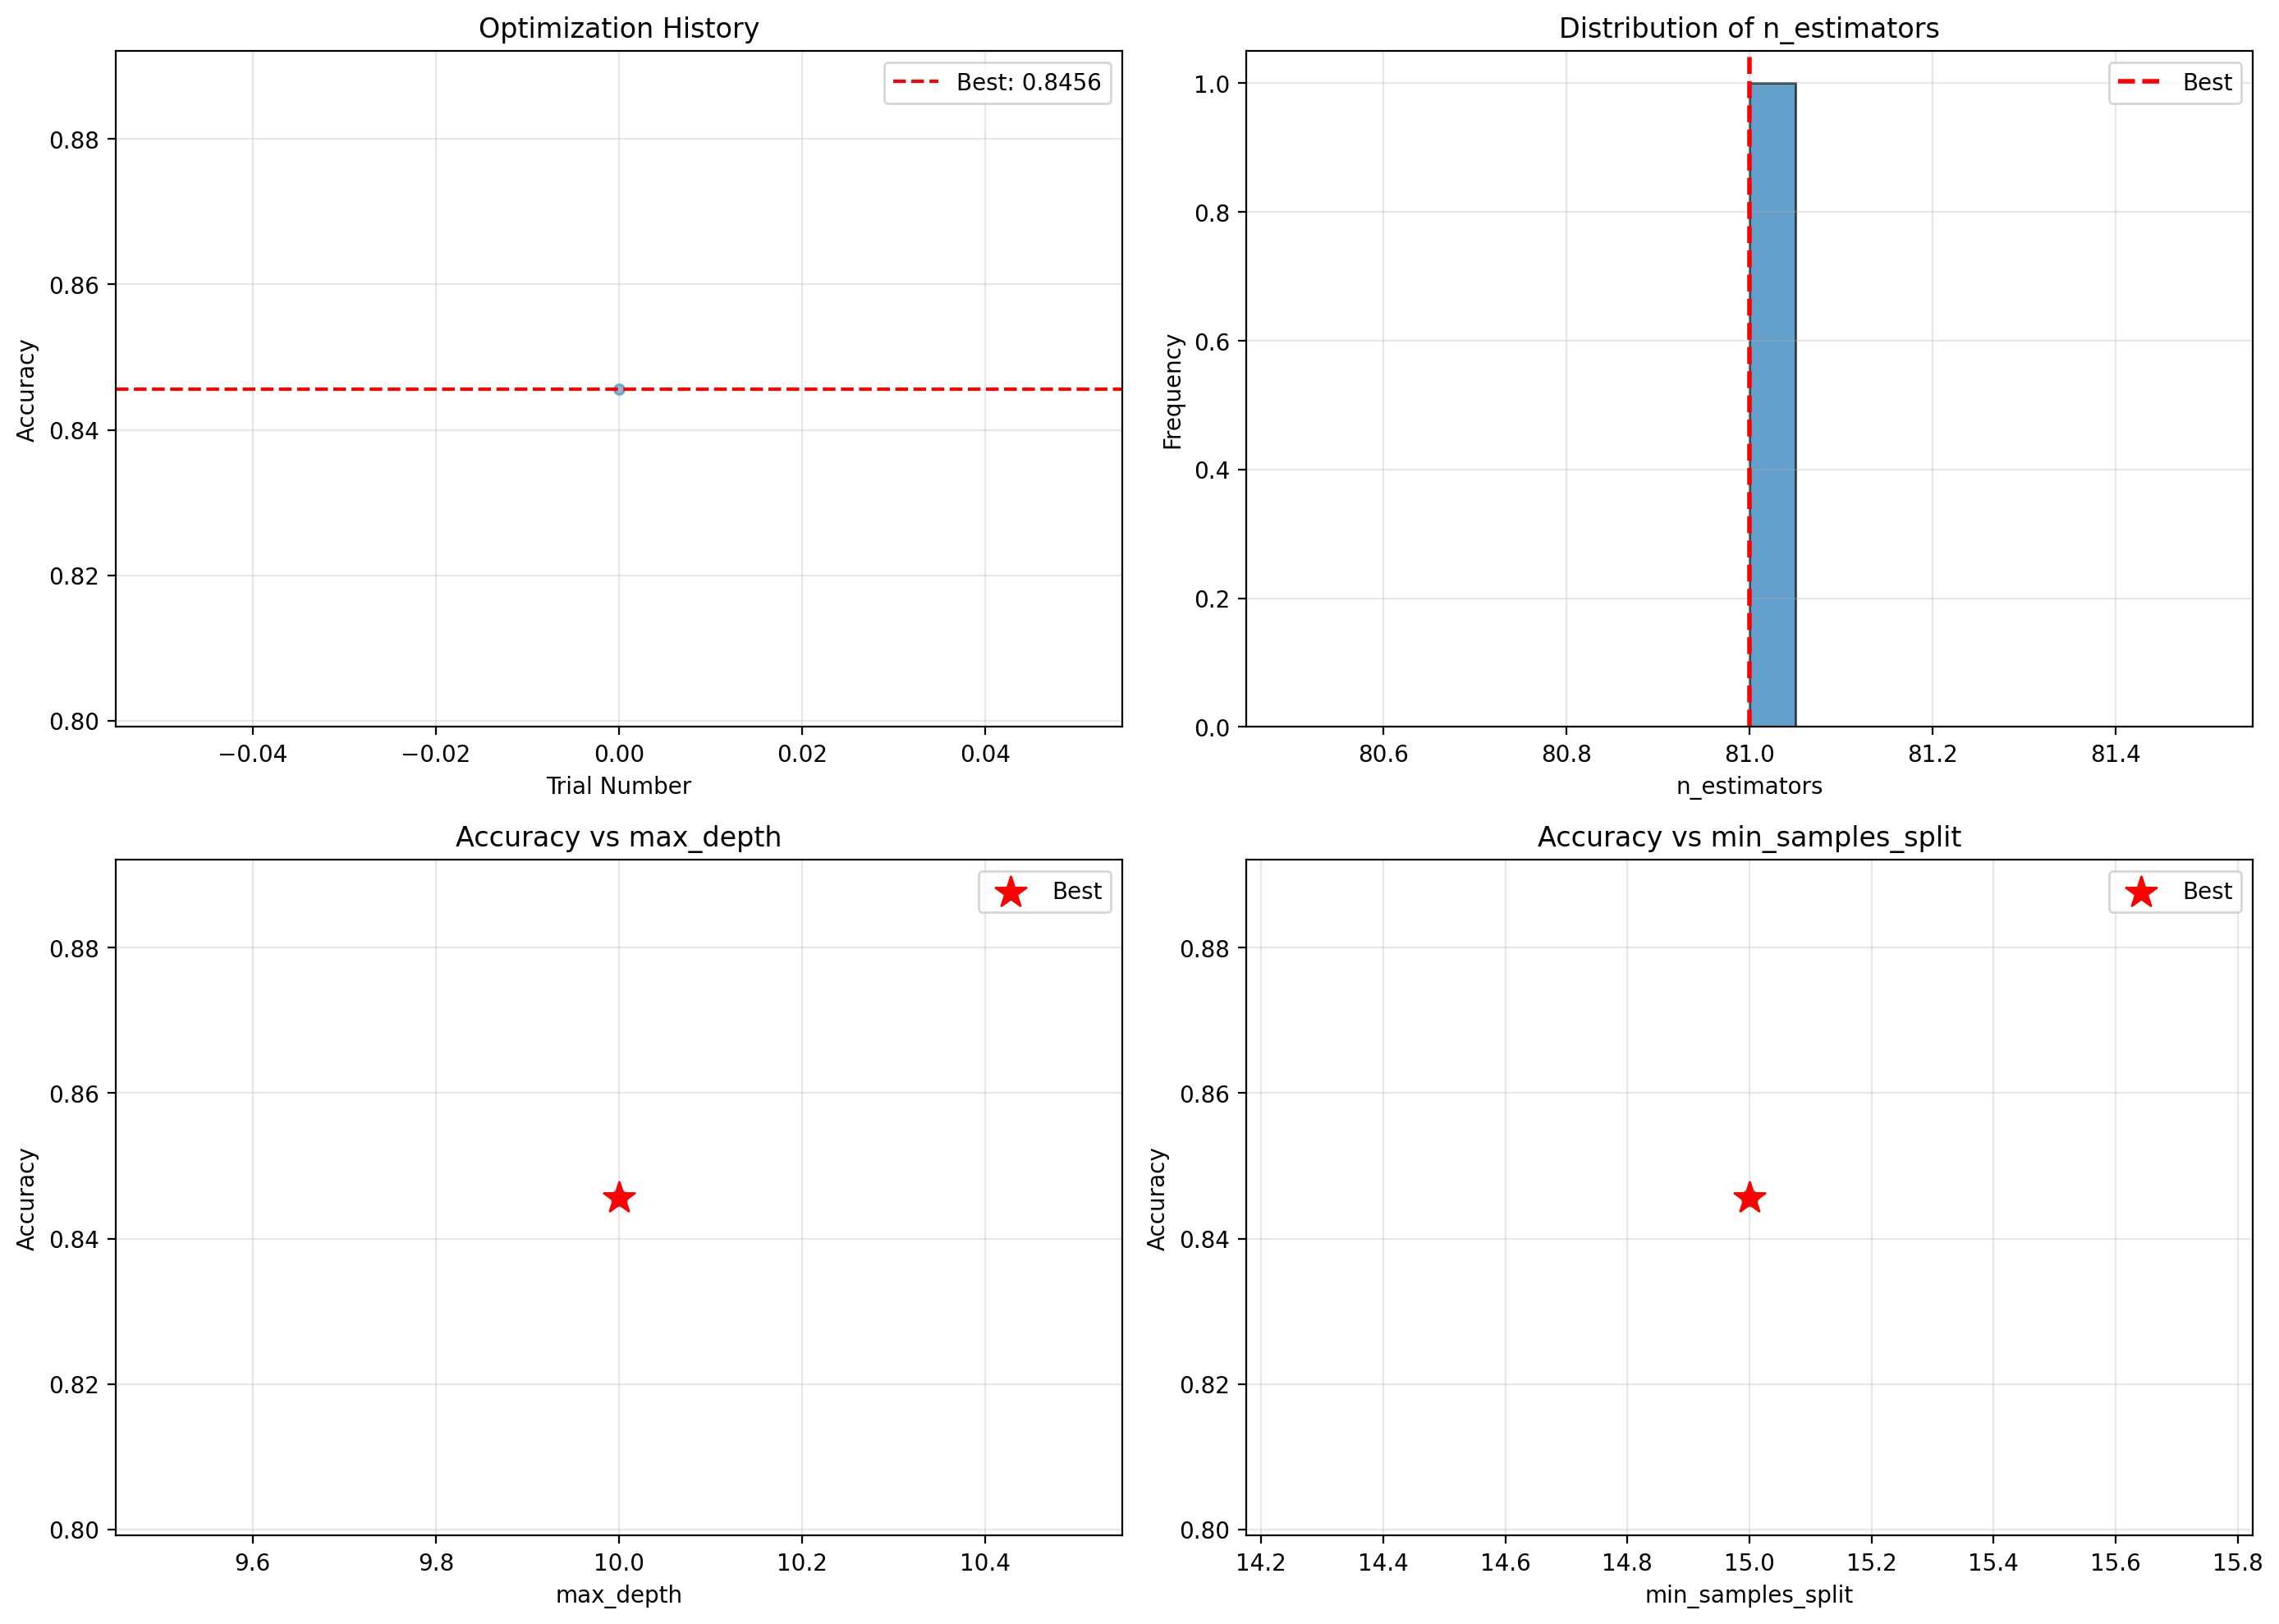

Visualization complete!


In [15]:
# Visualize Optuna optimization history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Optimization history (trial value over trials)
trials_df = study.trials_dataframe()
axes[0, 0].plot(
    range(len(trials_df)), trials_df["value"].values, "b-", alpha=0.6, linewidth=1
)
axes[0, 0].scatter(range(len(trials_df)), trials_df["value"].values, s=20, alpha=0.5)
axes[0, 0].axhline(
    y=best_trial.value, color="r", linestyle="--", label=f"Best: {best_trial.value:.4f}"
)
axes[0, 0].set_xlabel("Trial Number")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].set_title("Optimization History")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Distribution of n_estimators in trials
n_est_values = [trial.params.get("n_estimators") for trial in study.trials]
axes[0, 1].hist(n_est_values, bins=20, alpha=0.7, edgecolor="black")
axes[0, 1].axvline(
    x=best_params["n_estimators"], color="r", linestyle="--", linewidth=2, label="Best"
)
axes[0, 1].set_xlabel("n_estimators")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Distribution of n_estimators")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Accuracy vs max_depth
max_depth_values = [trial.params.get("max_depth") for trial in study.trials]
accuracy_values = [trial.value for trial in study.trials]
axes[1, 0].scatter(max_depth_values, accuracy_values, alpha=0.6, s=50)
axes[1, 0].scatter(
    [best_params["max_depth"]],
    [best_trial.value],
    color="r",
    s=200,
    marker="*",
    label="Best",
    zorder=5,
)
axes[1, 0].set_xlabel("max_depth")
axes[1, 0].set_ylabel("Accuracy")
axes[1, 0].set_title("Accuracy vs max_depth")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Accuracy vs min_samples_split
min_split_values = [trial.params.get("min_samples_split") for trial in study.trials]
axes[1, 1].scatter(min_split_values, accuracy_values, alpha=0.6, s=50, c="green")
axes[1, 1].scatter(
    [best_params["min_samples_split"]],
    [best_trial.value],
    color="r",
    s=200,
    marker="*",
    label="Best",
    zorder=5,
)
axes[1, 1].set_xlabel("min_samples_split")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].set_title("Accuracy vs min_samples_split")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Visualization complete!")

In [16]:
# Optional: Optimize for both targets with a reusable function
def optimize_rf_for_all_targets(X_train_data, y_data, feature_label, n_trials=50):
    """
    Optimize Random Forest for all targets and return results.

    Args:
        X_train_data: Training features
        y_data: Dictionary with target names as keys and target Series as values
        feature_label: Label for feature set (e.g., "Base" or "Engineered")
        n_trials: Number of trials for each target

    Returns:
        results: Dictionary with optimization results for each target
    """
    results = {}

    for target_name, y in y_data.items():
        print(f"\n{'=' * 80}")
        print(
            f"Optimizing for {target_name} ({feature_label} Features) - {n_trials} trials"
        )
        print(f"{'=' * 80}")

        X_train, X_test, y_train, y_test = split_data(
            X_train_data, y, test_size=0.2, random_state=42
        )

        best_params, study, best_trial = create_optuna_rf_optimizer(
            X_train, y_train, n_trials=n_trials, cv_folds=5
        )

        # Train final model
        final_model = RandomForestClassifier(**best_params, n_jobs=-1, random_state=42)
        final_model.fit(X_train, y_train)

        # Get test metrics
        y_pred = final_model.predict(X_test)
        test_metrics = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred),
            "Recall": recall_score(y_test, y_pred),
            "F1": f1_score(y_test, y_pred),
        }

        results[target_name] = {
            "best_params": best_params,
            "best_score": best_trial.value,
            "test_metrics": test_metrics,
            "model": final_model,
            "study": study,
        }

        print(f"Best Accuracy (CV): {best_trial.value:.4f}")
        print(f"Test Accuracy: {test_metrics['Accuracy']:.4f}")

    return results


# Uncomment below to optimize for both targets (this may take a while):
# targets = {"IncomeInvestment": y_income, "AccumulationInvestment": y_accum}
# all_results = optimize_rf_for_all_targets(final_X, targets, "Engineered", n_trials=50)

# Save results summary using tuned IncomeInvestment params
print("\n" + "=" * 80)
print("OPTUNA OPTIMIZATION SUMMARY")
print("=" * 80)
print("\nTo apply optimized hyperparameters in your pipeline:")
print("\n```python")
print("optimized_rf = RandomForestClassifier(")
for key, value in best_params.items():
    if isinstance(value, str):
        print(f"    {key}='{value}',")
    else:
        print(f"    {key}={value},")
print("    n_jobs=-1,")
print("    random_state=42")
print(")")
print("\nmodel = create_pipeline(optimized_rf)")
print("```")


OPTUNA OPTIMIZATION SUMMARY

To apply optimized hyperparameters in your pipeline:

```python
optimized_rf = RandomForestClassifier(
    n_estimators=81,
    max_depth=10,
    min_samples_split=15,
    min_samples_leaf=6,
    max_features='sqrt',
    bootstrap=True,
    criterion='gini',
    n_jobs=-1,
    random_state=42
)

model = create_pipeline(optimized_rf)
```


## Tuning for lightgbm


In [17]:
def create_optuna_lgbm_optimizer(X_train, y_train, n_trials=20, cv_folds=5):
    """
    Create and run an Optuna study to optimize LightGBM hyperparameters.

    Args:
        X_train: Training features
        y_train: Training labels
        n_trials: Number of trials for Optuna to run
        cv_folds: Number of cross-validation folds

    Returns:
        best_params: Dictionary of best hyperparameters
        study: Optuna study object
        best_trial: Best trial object
    """

    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 50, 500),
            "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 15, 255),
            "max_depth": trial.suggest_int("max_depth", -1, 20),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "random_state": 42,
            "verbosity": -1,
            "force_col_wise": True,
        }

        lgbm_model = create_pipeline(
            classifier=LGBMClassifier(**params),
            apple_feat_eng=True,
        )

        cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
        precision_scores = []

        for train_idx, val_idx in cv.split(X_train, y_train):
            X_train_fold, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_train_fold, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

            lgbm_model.fit(X_train_fold, y_train_fold)
            y_pred = lgbm_model.predict(X_val_fold)
            precision_scores.append(
                precision_score(y_val_fold, y_pred, zero_division=0)
            )

        return np.mean(precision_scores)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )

    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_trial = study.best_trial
    best_params = best_trial.params

    return best_params, study, best_trial


In [18]:
LGBM_N_TRIALS = 1
lgbm_tuning_results = {}

for target_label, y_target in [
    ("Income Investment", y_income),
    ("Accumulation Investment", y_accum),
]:
    print("\n" + "=" * 80)
    print(f"OPTUNA HYPERPARAMETER TUNING FOR LIGHTGBM - {target_label}")
    print("=" * 80)

    X_train_lgbm, X_test_lgbm, y_train_lgbm, y_test_lgbm = split_data(final_X, y_target)

    best_lgbm_params, lgbm_study, lgbm_best_trial = create_optuna_lgbm_optimizer(
        X_train_lgbm, y_train_lgbm, n_trials=LGBM_N_TRIALS, cv_folds=5
    )

    print(f"\nOptimization completed in {len(lgbm_study.trials)} trials")
    print(f"Best Precision (CV): {lgbm_best_trial.value:.4f}")
    print("\nBest Hyperparameters:")
    for key, value in best_lgbm_params.items():
        print(f"  {key}: {value}")

    # Compare baseline vs optimized LightGBM
    baseline_lgbm = create_pipeline(
        classifier=LGBMClassifier(
            n_estimators=100,
            learning_rate=0.05,
            num_leaves=31,
            random_state=42,
            importance_type="gain",
            verbosity=-1,
            force_col_wise=True,
        ),
        apple_feat_eng=True,
    )

    optimized_lgbm = create_pipeline(
        classifier=LGBMClassifier(
            **best_lgbm_params,
            random_state=42,
            verbosity=-1,
            force_col_wise=True,
        ),
        apple_feat_eng=True,
    )

    baseline_lgbm.fit(X_train_lgbm, y_train_lgbm)
    optimized_lgbm.fit(X_train_lgbm, y_train_lgbm)

    baseline_pred = baseline_lgbm.predict(X_test_lgbm)
    optimized_pred = optimized_lgbm.predict(X_test_lgbm)

    baseline_metrics = {
        "Accuracy": accuracy_score(y_test_lgbm, baseline_pred),
        "Precision": precision_score(y_test_lgbm, baseline_pred, zero_division=0),
        "Recall": recall_score(y_test_lgbm, baseline_pred, zero_division=0),
        "F1": f1_score(y_test_lgbm, baseline_pred, zero_division=0),
    }
    optimized_metrics = {
        "Accuracy": accuracy_score(y_test_lgbm, optimized_pred),
        "Precision": precision_score(y_test_lgbm, optimized_pred, zero_division=0),
        "Recall": recall_score(y_test_lgbm, optimized_pred, zero_division=0),
        "F1": f1_score(y_test_lgbm, optimized_pred, zero_division=0),
    }

    print("\n" + "-" * 80)
    print(f"LIGHTGBM BASELINE vs OPTIMIZED (Test Set) - {target_label}")
    print("-" * 80)
    for metric_name in ["Accuracy", "Precision", "Recall", "F1"]:
        print(f"Baseline {metric_name}:  {baseline_metrics[metric_name]:.4f}")
        print(f"Optimized {metric_name}: {optimized_metrics[metric_name]:.4f}")

    lgbm_tuning_results[target_label] = {
        "best_params": best_lgbm_params,
        "best_precision_cv": lgbm_best_trial.value,
        "baseline_metrics": baseline_metrics,
        "optimized_metrics": optimized_metrics,
        "study": lgbm_study,
    }

[I 2026-04-18 22:44:52,853] A new study created in memory with name: no-name-344e49d8-69f8-4597-8ffb-bd18d43b851a



OPTUNA HYPERPARAMETER TUNING FOR LIGHTGBM - Income Investment


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-04-18 22:44:56,133] Trial 0 finished with value: 0.7749221979033838 and parameters: {'n_estimators': 218, 'learning_rate': 0.1540359659501924, 'num_leaves': 191, 'max_depth': 12, 'min_child_samples': 19, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.7749221979033838.

Optimization completed in 1 trials
Best Precision (CV): 0.7749

Best Hyperparameters:
  n_estimators: 218
  learning_rate: 0.1540359659501924
  num_leaves: 191
  max_depth: 12
  min_child_samples: 19
  subsample: 0.662397808134481
  colsample_bytree: 0.6232334448672797
  reg_alpha: 0.6245760287469893
  reg_lambda: 0.002570603566117598


[I 2026-04-18 22:44:57,447] A new study created in memory with name: no-name-bb93222f-62fd-4bba-97f8-5fcdd6cf5872



--------------------------------------------------------------------------------
LIGHTGBM BASELINE vs OPTIMIZED (Test Set) - Income Investment
--------------------------------------------------------------------------------
Baseline Accuracy:  0.7840
Optimized Accuracy: 0.7630
Baseline Precision:  0.8443
Optimized Precision: 0.7753
Baseline Recall:  0.5365
Optimized Recall: 0.5391
Baseline F1:  0.6561
Optimized F1: 0.6359

OPTUNA HYPERPARAMETER TUNING FOR LIGHTGBM - Accumulation Investment


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-04-18 22:45:00,343] Trial 0 finished with value: 0.8403306716094372 and parameters: {'n_estimators': 218, 'learning_rate': 0.1540359659501924, 'num_leaves': 191, 'max_depth': 12, 'min_child_samples': 19, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598}. Best is trial 0 with value: 0.8403306716094372.

Optimization completed in 1 trials
Best Precision (CV): 0.8403

Best Hyperparameters:
  n_estimators: 218
  learning_rate: 0.1540359659501924
  num_leaves: 191
  max_depth: 12
  min_child_samples: 19
  subsample: 0.662397808134481
  colsample_bytree: 0.6232334448672797
  reg_alpha: 0.6245760287469893
  reg_lambda: 0.002570603566117598

--------------------------------------------------------------------------------
LIGHTGBM BASELINE vs OPTIMIZED (Test Set) - Accumulation Investment
--------------------------------------------------------------------------------
Baseline Accuracy:  0.8210
Op

# 7. Explainable AI (XAI) — Model Interpretability

We apply SHAP, LIME, and permutation importance to understand which features drive the model's predictions.


**Explainable AI applied on Random Forest**


- **Shap Analysis**


In [19]:
# Train and store final Random Forest models for XAI analysis
best_rf_models = {}

# Train model for Income Investment with Engineered features
print("\n" + "=" * 80)
print("Training final Random Forest models for XAI analysis")
print("=" * 80)

# Income Investment with Engineered features
print("\nTraining: Income Investment (Engineered Features)")
X_train_income_eng, X_test_income_eng, y_train_income, y_test_income = split_data(
    final_X, y_income
)
rf_income_eng = create_pipeline(
    RandomForestClassifier(**best_params, n_jobs=-1, random_state=42),
    apple_feat_eng=True,
)
rf_income_eng.fit(X_train_income_eng, y_train_income)
y_pred_income_eng = rf_income_eng.predict(X_test_income_eng)
print(f"Test Accuracy: {accuracy_score(y_test_income, y_pred_income_eng):.4f}")
print(f"Test Precision: {precision_score(y_test_income, y_pred_income_eng):.4f}")
best_rf_models[("Income Investment", "Engineered")] = rf_income_eng

# Accumulation Investment with Engineered features
print("\nTraining: Accumulation Investment (Engineered Features)")
X_train_accum_eng, X_test_accum_eng, y_train_accum, y_test_accum = split_data(
    final_X, y_accum
)
rf_accum_eng = create_pipeline(
    RandomForestClassifier(**best_params_accum, n_jobs=-1, random_state=42),
    apple_feat_eng=True,
)
rf_accum_eng.fit(X_train_accum_eng, y_train_accum)
y_pred_accum_eng = rf_accum_eng.predict(X_test_accum_eng)
print(f"Test Accuracy: {accuracy_score(y_test_accum, y_pred_accum_eng):.4f}")
print(f"Test Precision: {precision_score(y_test_accum, y_pred_accum_eng):.4f}")
best_rf_models[("Accumulation Investment", "Engineered")] = rf_accum_eng

print("\n" + "=" * 80)
print("Models ready for XAI analysis")
print("=" * 80)


Training final Random Forest models for XAI analysis

Training: Income Investment (Engineered Features)
Test Accuracy: 0.7780
Test Precision: 0.8240

Training: Accumulation Investment (Engineered Features)
Test Accuracy: 0.8040
Test Precision: 0.8409

Models ready for XAI analysis



Analyzing: Income Investment


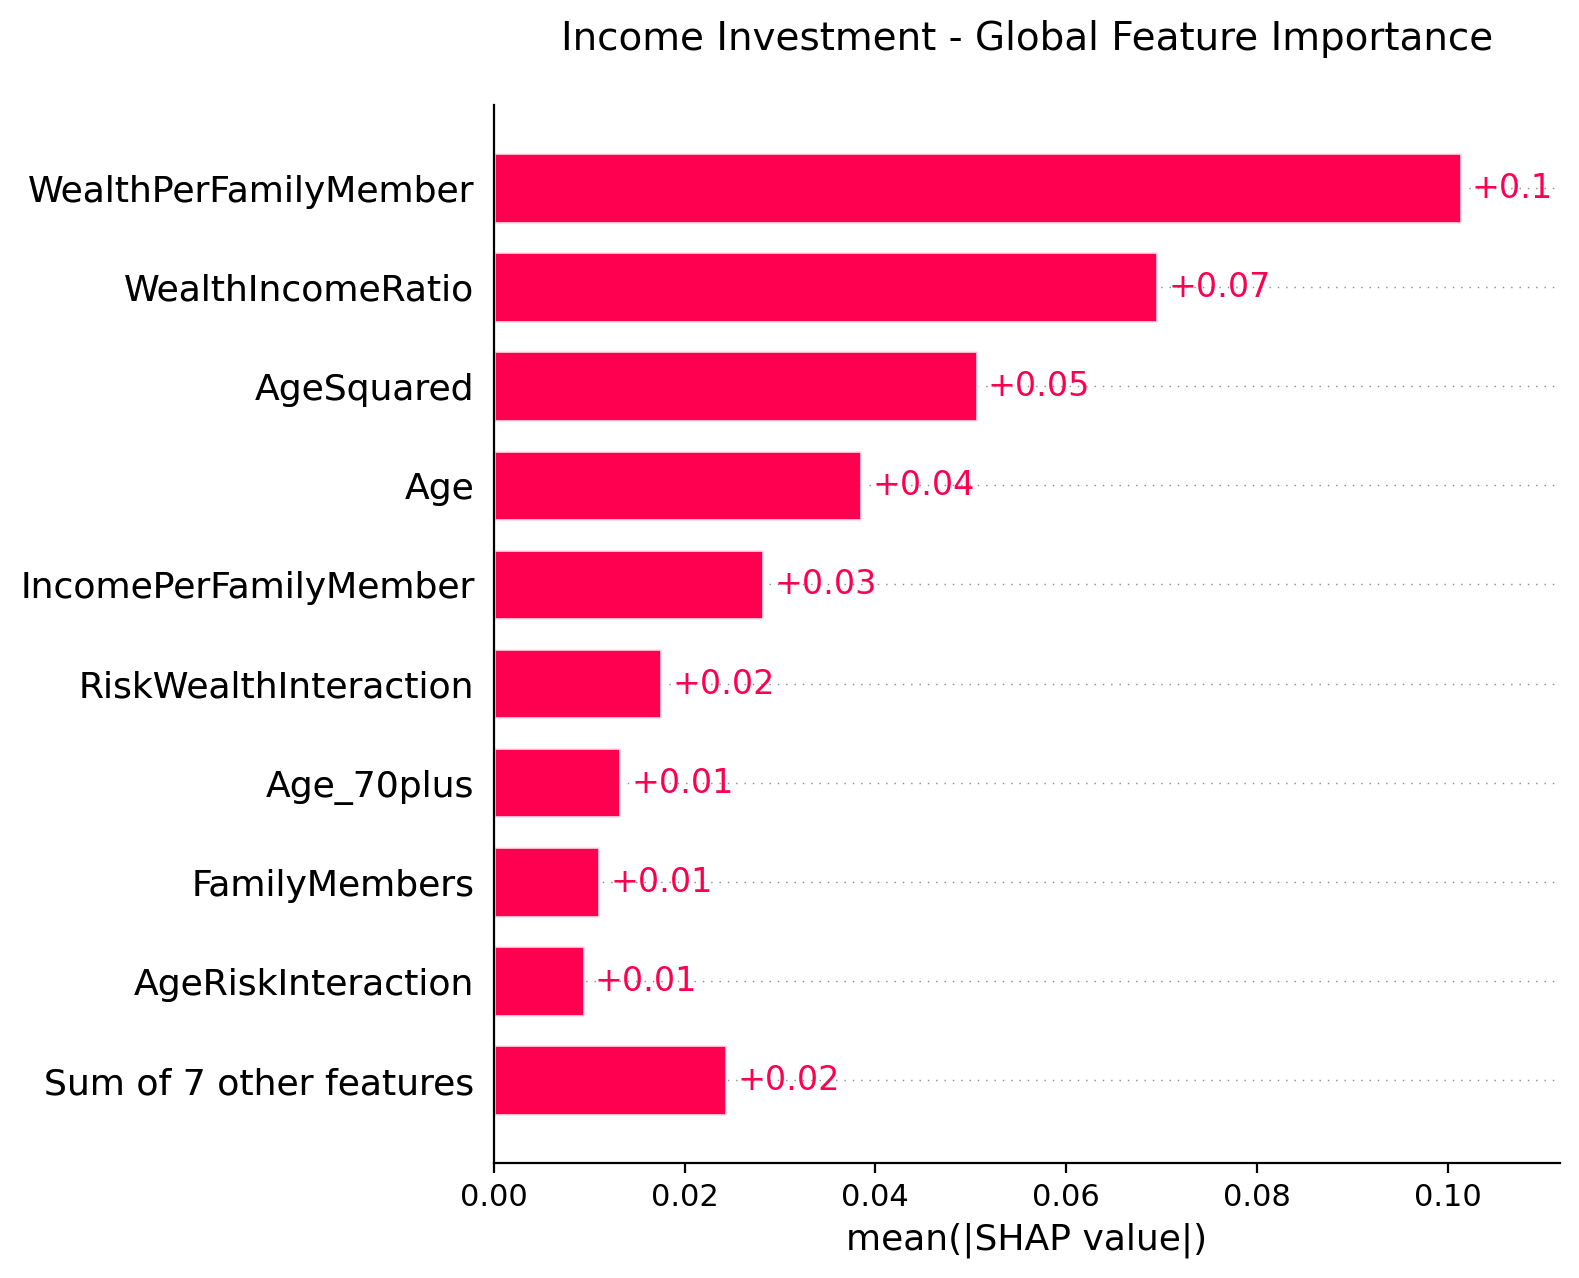

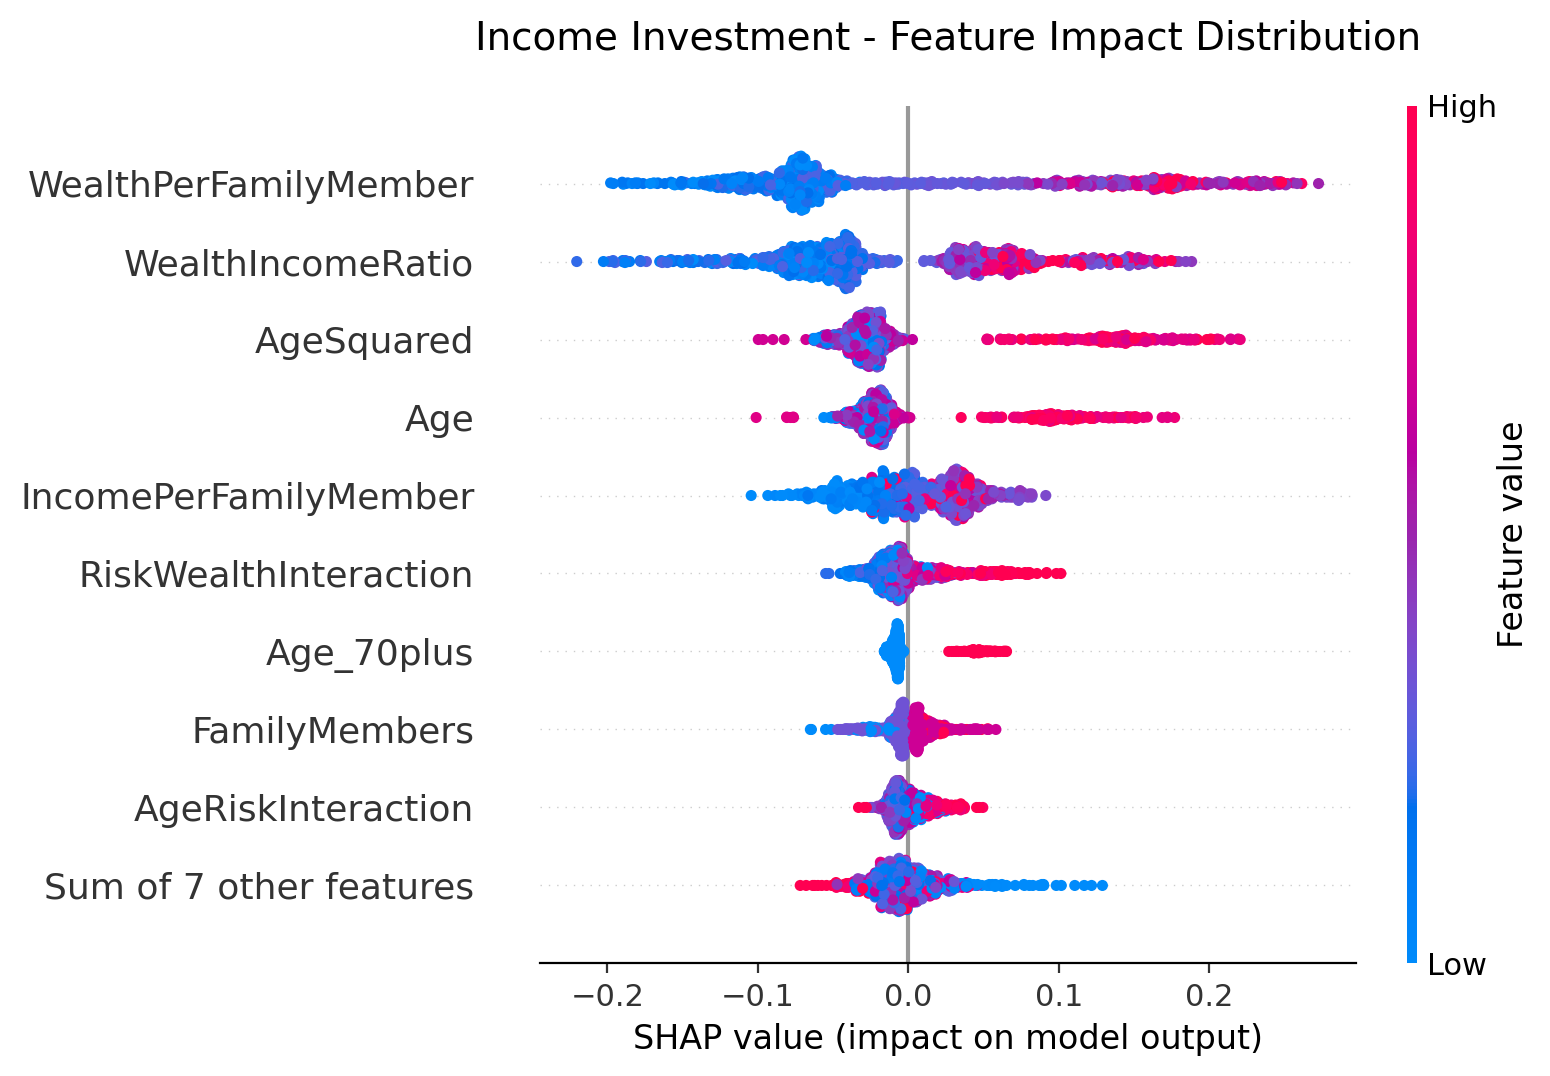


Analyzing: Accumulation Investment


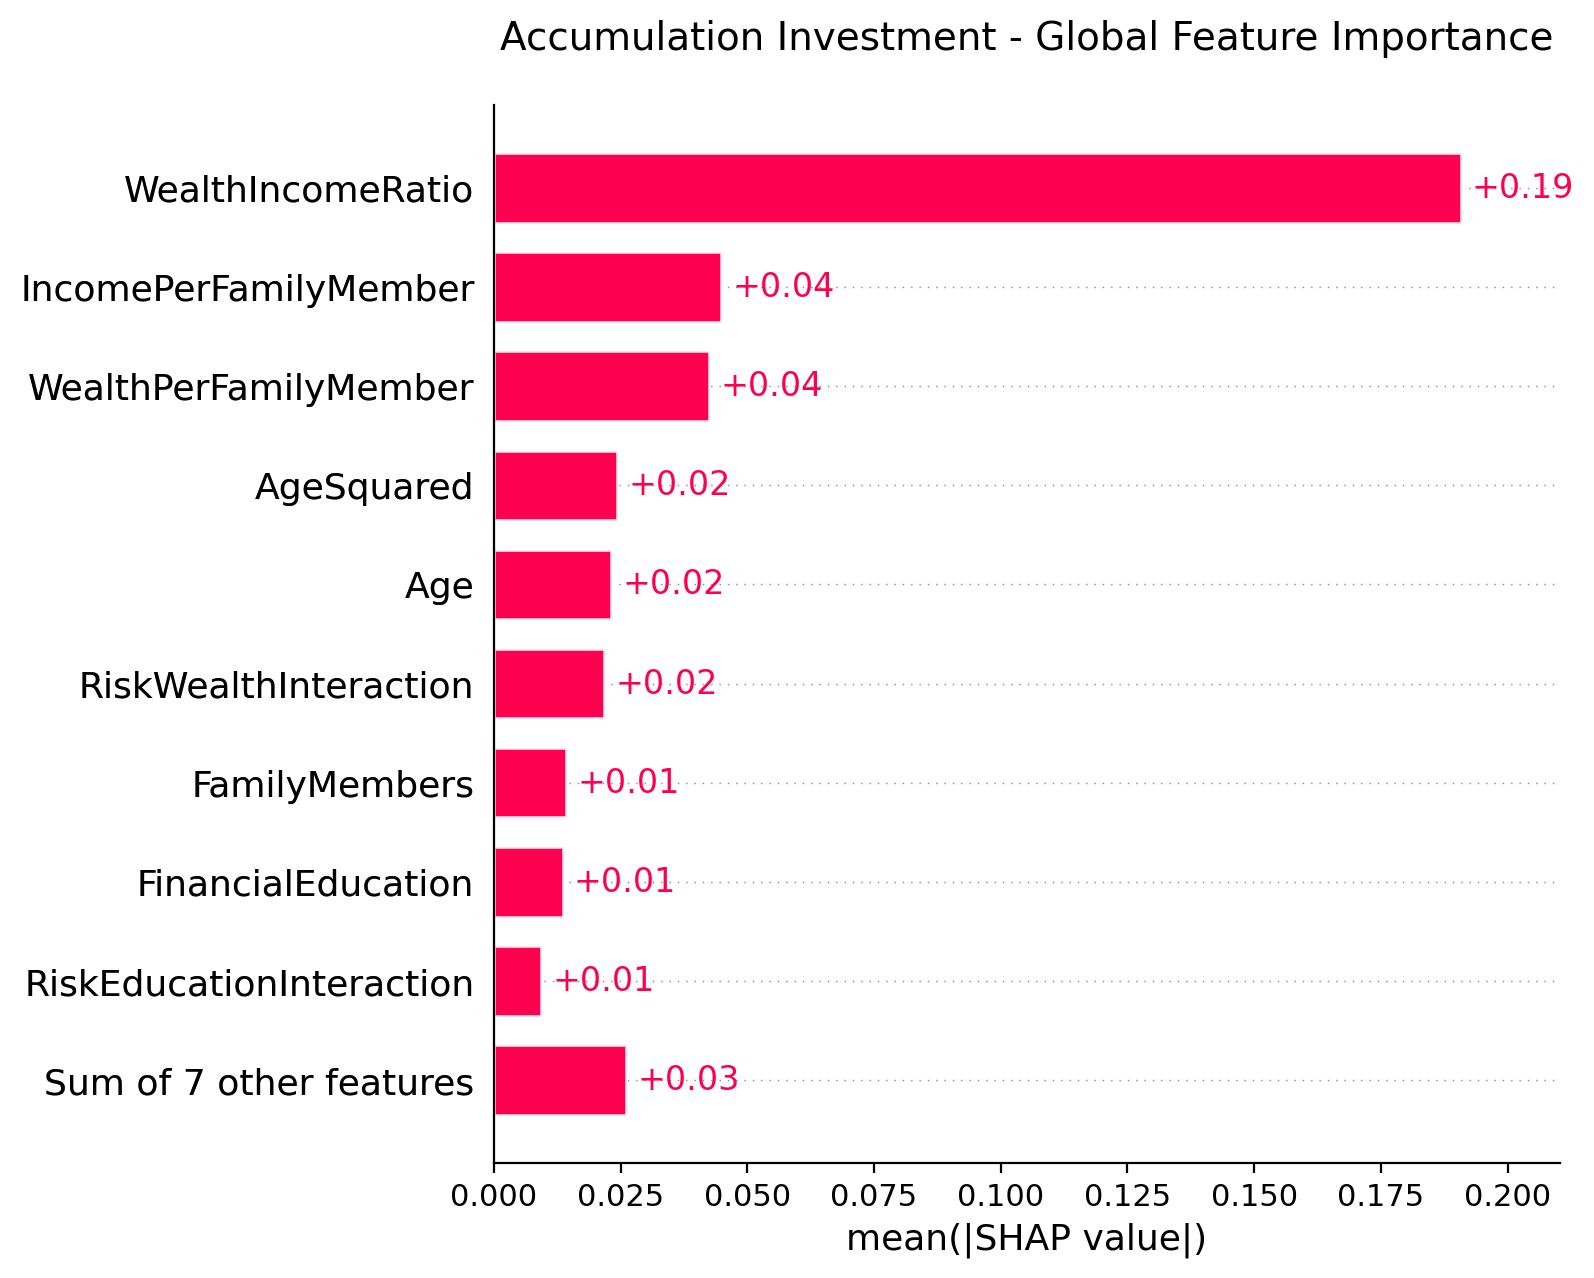

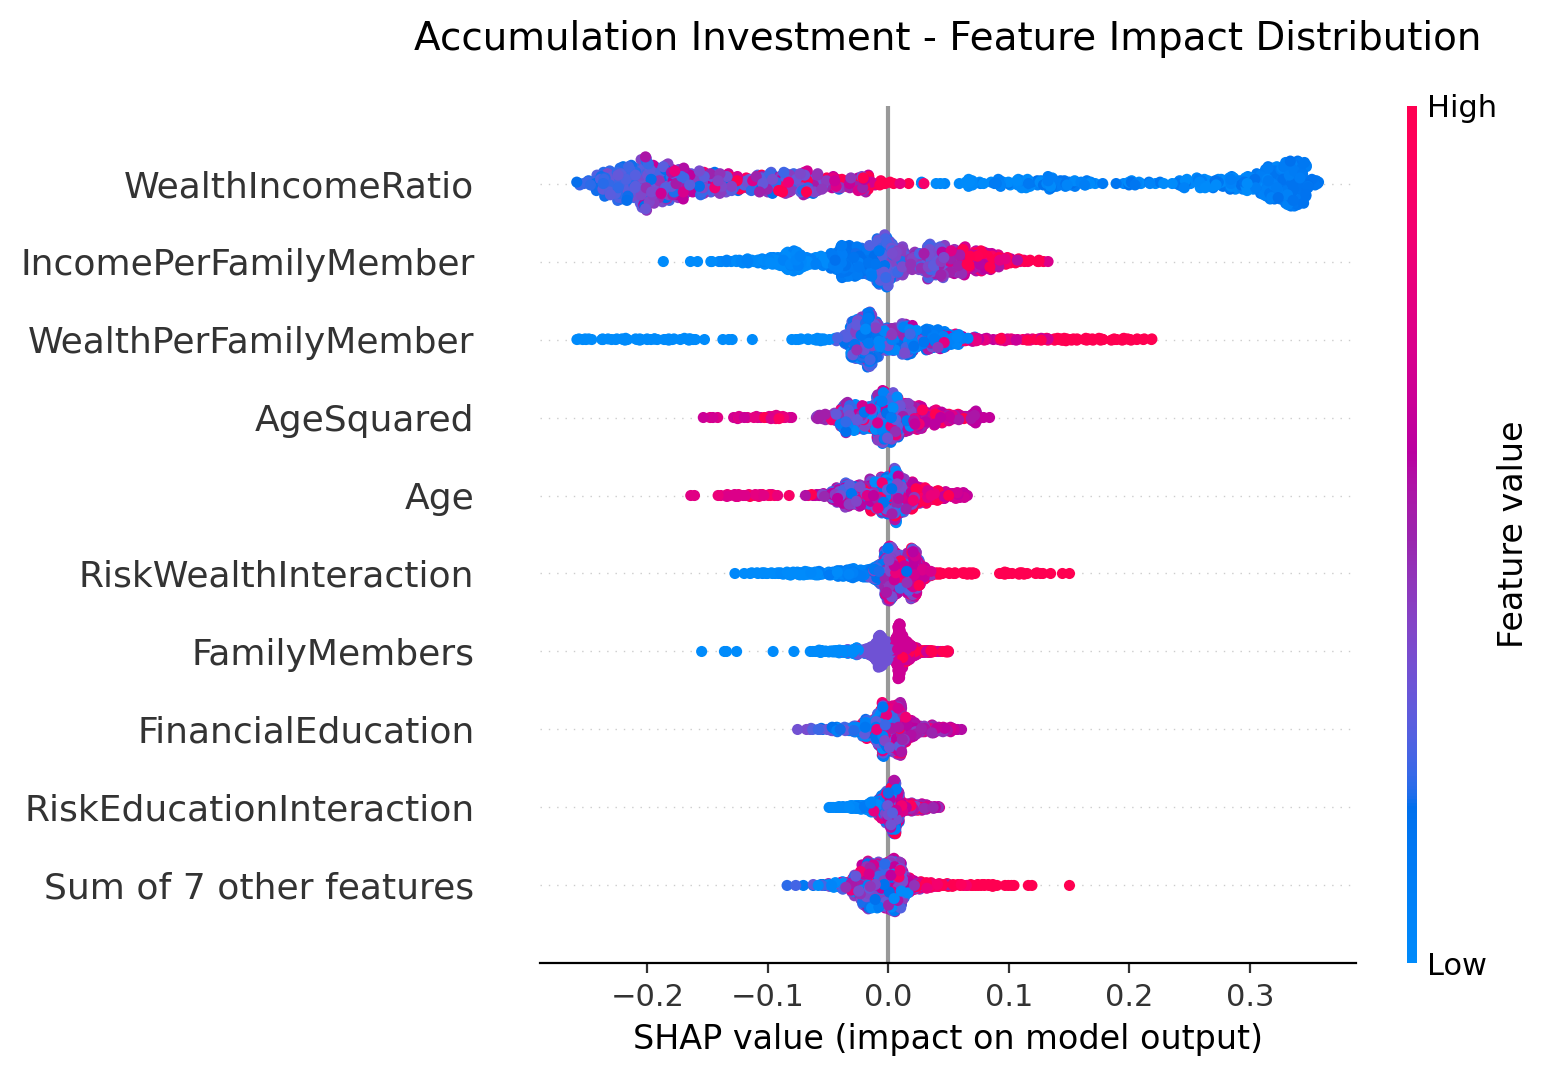

In [20]:
import matplotlib.pyplot as plt
import shap


def plot_shap_values(model, X, title):
    # 1. Initialize Explainer
    rf = model.named_steps["classifier"]
    X_transformed = model[:-1].transform(X)
    explainer = shap.TreeExplainer(rf)

    # 2. Get SHAP values
    shap_results = explainer(X_transformed, check_additivity=False)

    # 3. Handle Slicing for Random Forest (Class 1)
    if len(shap_results.shape) == 3:
        display_shap = shap_results[:, :, 1]
    else:
        display_shap = shap_results

    # Plot 1: Bar Plot (Global Importance)
    plt.figure(figsize=(10, 6))
    shap.plots.bar(display_shap, max_display=10, show=False)
    plt.title(f"{title} - Global Feature Importance", fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

    # Plot 2: Beeswarm (Feature Impacts)
    plt.figure(figsize=(10, 6))
    plt.title(f"{title} - Feature Impact Distribution", fontsize=14, pad=20)
    shap.plots.beeswarm(display_shap, max_display=10, show=False)
    plt.xlabel("SHAP value (impact on model output)", fontsize=12)
    plt.tight_layout()
    plt.show()


for target_name in ["Income Investment", "Accumulation Investment"]:
    print(f"\nAnalyzing: {target_name}")
    model = best_rf_models[(target_name, "Engineered")]
    y_target = y_income if target_name == "Income Investment" else y_accum
    _, X_test_eng, _, _ = split_data(final_X, y_target)

    plot_shap_values(model, X_test_eng, target_name)


**SHAP analysis**:
For Income Investment, the model is primarily driven by high WealthPerFamilyMember, where concentrated wealth directly pushes the probability of needing income-generating products. In contrast, the Accumulation Investment model is dominated by the WealthIncomeRatio, but with a crucial inverse relationship: low values of this ratio (represented by the blue clusters on the right) are the strongest predictors for the target. This suggests the model successfully identifies "high-potential accumulators".


- **Individual shap**


Client Profile:


,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth
299,38,1,3,0.42,0.38,44.58,40.63


--- Individual SHAP Explanation: Income Investment ---
Client Index: 0
Probability of Investment: 0.1990
Final Prediction: Non-Investor
--------------------------------------------------


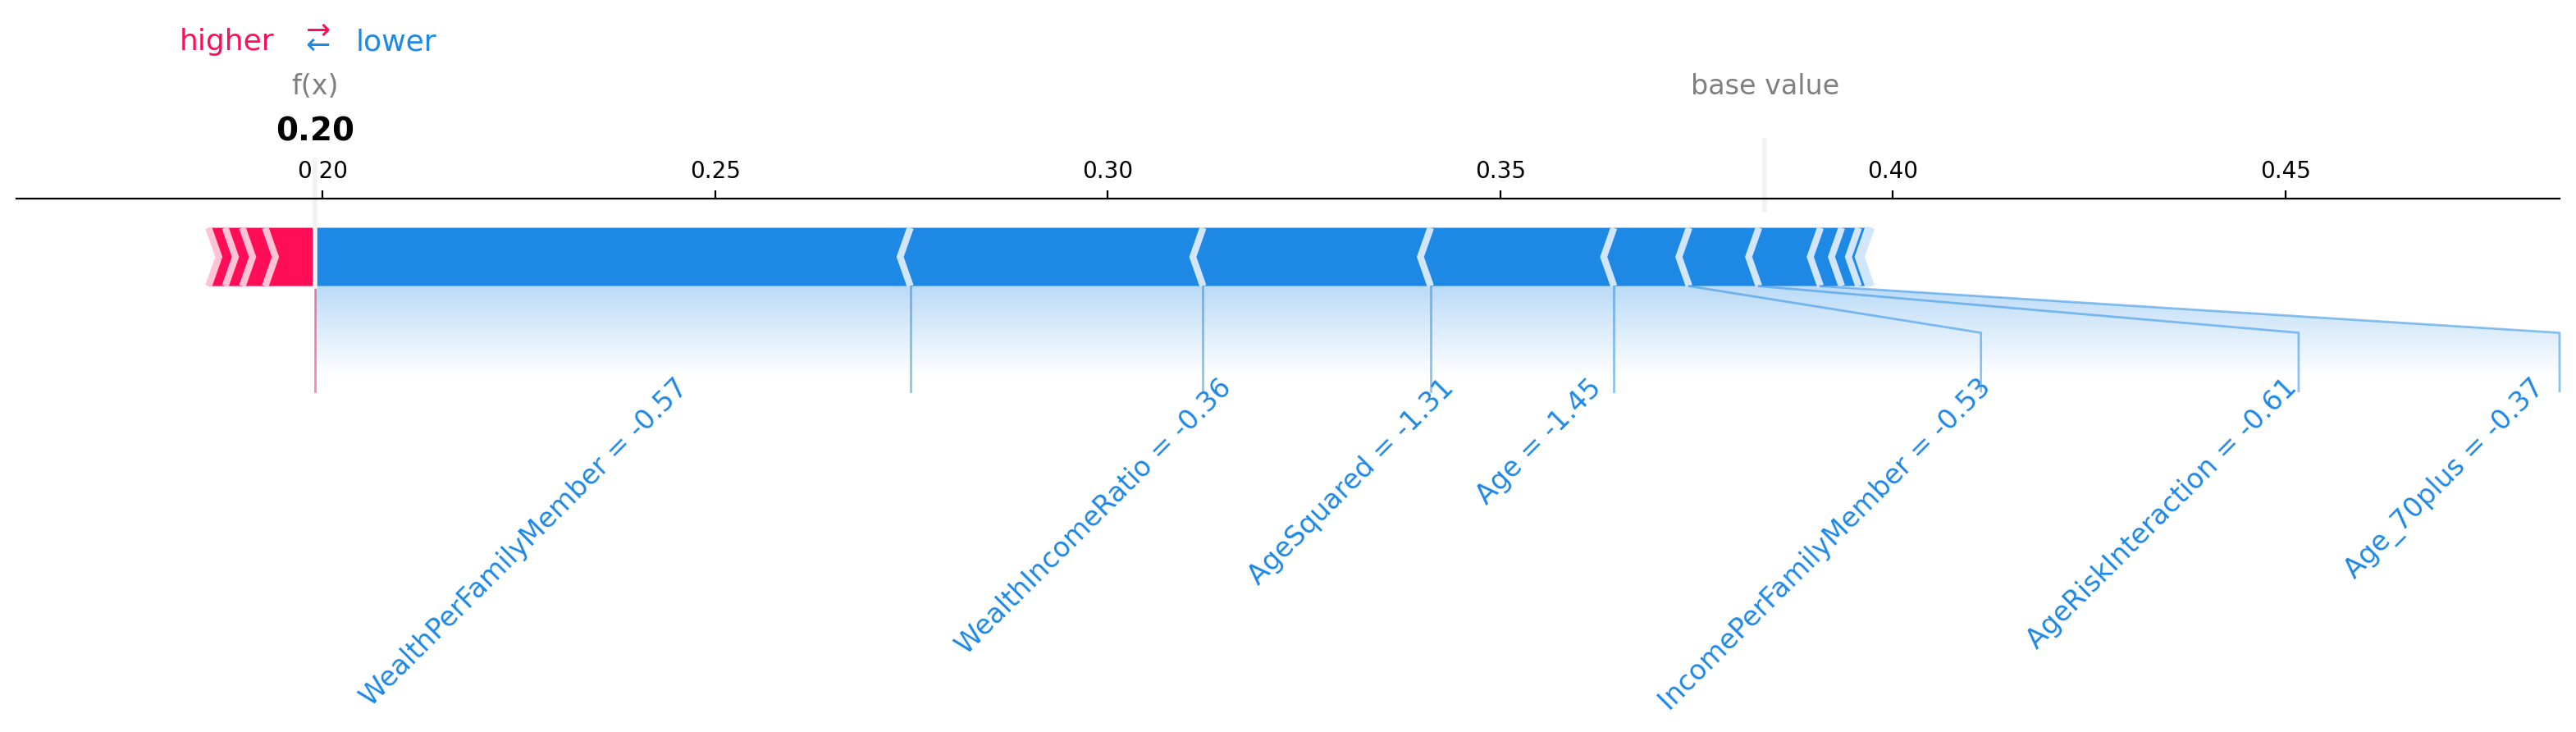

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import shap

# 1. Configuration
target_to_explain = "Income Investment"
model = best_rf_models[(target_to_explain, "Engineered")]
y_target = y_income if target_to_explain == "Income Investment" else y_accum

# 2. Prepare Data
_, X_test_local, _, _ = split_data(final_X, y_target)

# 3. Initialize Explainer and Calculate SHAP values for the specific individual
rf = model.named_steps["classifier"]
explainer = shap.TreeExplainer(rf)
idx = 0  # first individual test set
client_row = X_test_local.iloc[[idx]]
print("Client Profile:")
display(client_row.round(2))
client_row_transformed = model[:-1].transform(client_row)
shap_results_local = explainer(client_row_transformed, check_additivity=False)

# 4. Extract values for the Force Plot
if len(shap_results_local.shape) == 3:
    # we select sample 0, all features, class 1
    sv = shap_results_local.values[0, :, 1]
    bv = shap_results_local.base_values[0, 1]
else:
    # we select sample 0
    sv = shap_results_local.values[0, :]
    bv = shap_results_local.base_values[0]

# 5. Print prediction context for analysis
prob = model.predict_proba(client_row)[0][1]
print(f"--- Individual SHAP Explanation: {target_to_explain} ---")
print(f"Client Index: {idx}")
print(f"Probability of Investment: {prob:.4f}")
print(f"Final Prediction: {'Investor' if prob > 0.5 else 'Non-Investor'}")
print("-" * 50)

shap.force_plot(
    bv,
    sv,
    client_row_transformed.round(2),
    matplotlib=True,
    show=True,
    contribution_threshold=0.05,
    text_rotation=45,
)


**Individual SHAP analysis**:
On the positive side, the client’s Risk-Wealth Interaction (0.26) and Risk Propensity (0.41) are the strongest drivers pushing the model toward an investment prediction. However, these are overpowered by negative pressures (blue), most notably a very low WealthPerFamilyMember (0.02) and a low WealthIncomeRatio (0.02). Effectively, while the model recognizes the client's high risk appetite and financial education, his current lack of accumulated wealth leads the model to ultimately predict a lower likelihood of investment.


- **Permutation importance**


/tmp/ipykernel_67640/2091854091.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


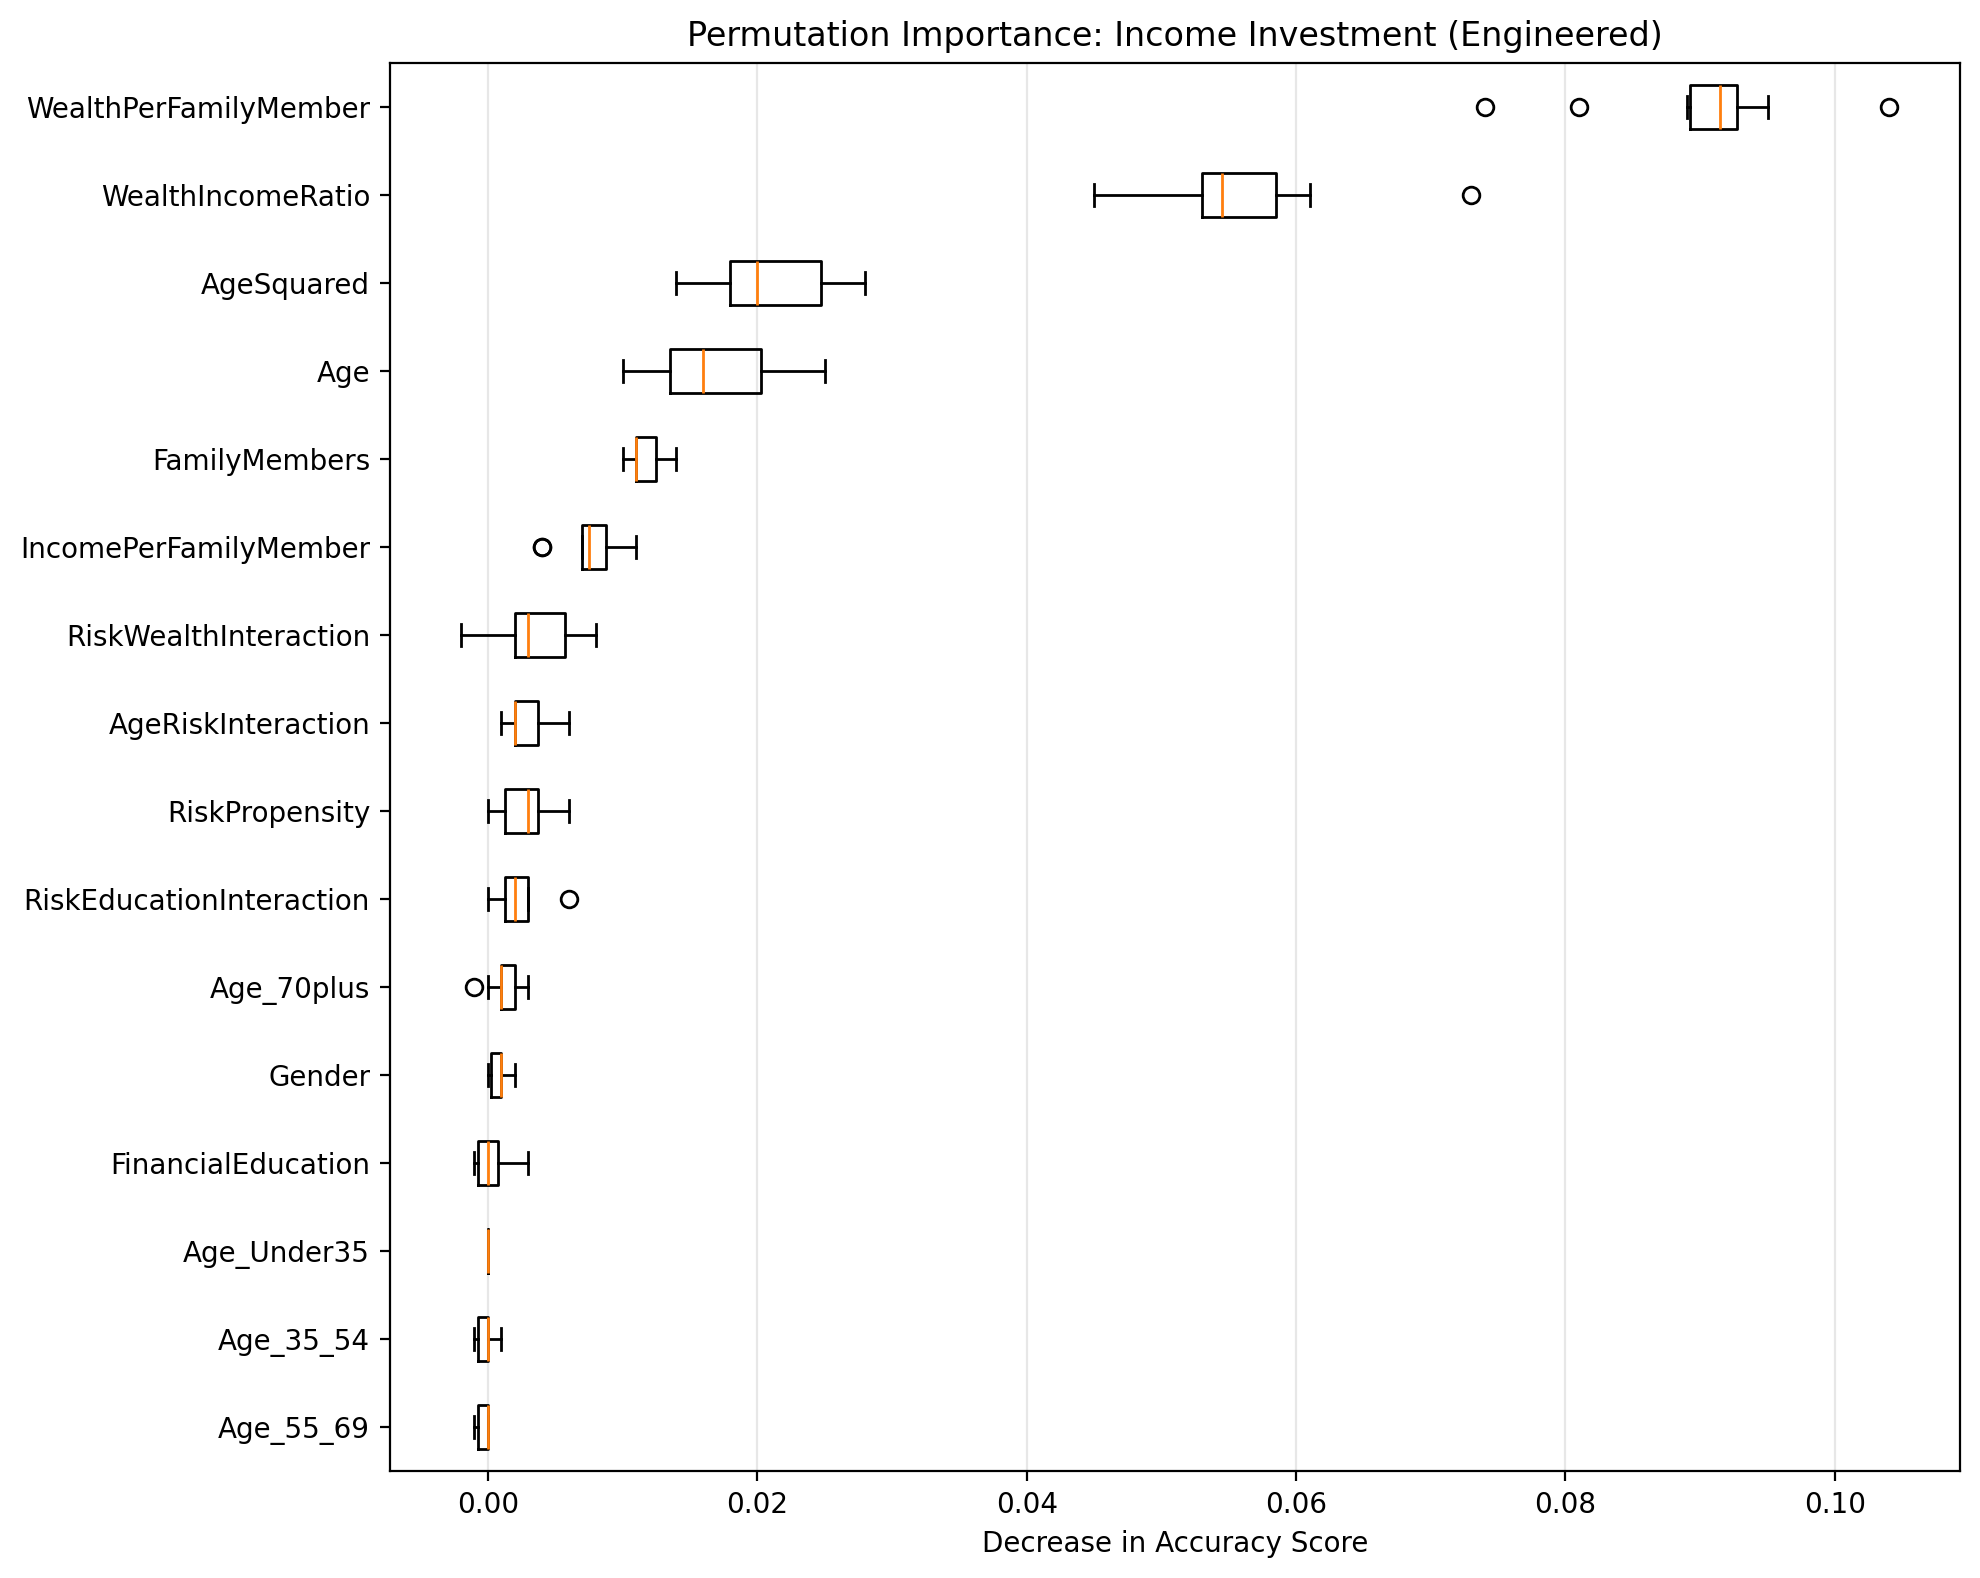

In [22]:
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

# 1. Selection
target_to_explain = "Income Investment"
model = best_rf_models[(target_to_explain, "Engineered")]
y_target = y_income if target_to_explain == "Income Investment" else y_accum

# 2. Get the test set
_, X_test, _, y_test = split_data(final_X, y_target)

# 3. Apply feature engineering and compute permutation importance on transformed features
X_test_transformed = model[:-1].transform(X_test)
classifier = model.named_steps["classifier"]
perm_importance = permutation_importance(
    classifier, X_test_transformed, y_test, n_repeats=10, random_state=42
)

# 4. Visualize with Boxplot
plt.figure(figsize=(10, 8))
sorted_idx = perm_importance.importances_mean.argsort()

plt.boxplot(
    perm_importance.importances[sorted_idx].T,
    vert=False,
    labels=X_test_transformed.columns[sorted_idx],
)

plt.title(f"Permutation Importance: {target_to_explain} (Engineered)")
plt.xlabel("Decrease in Accuracy Score")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

The Permutation Importance plot confirms that the model relies heavily on a small subset of features for its predictive accuracy. WealthPerFamilyMember is the most critical feature by a significant margin, as its removal causes a nearly 11% drop in accuracy, demonstrating high reliability and low variance. WealthIncomeRatio and Age/AgeSquared follow as the next most impactful variables. Notably, most interaction terms and demographic indicators are near zero, suggesting they are "nice-to-have" features that provide nuance but aren't vital for the model's core performance.


- **PDP and ICE**


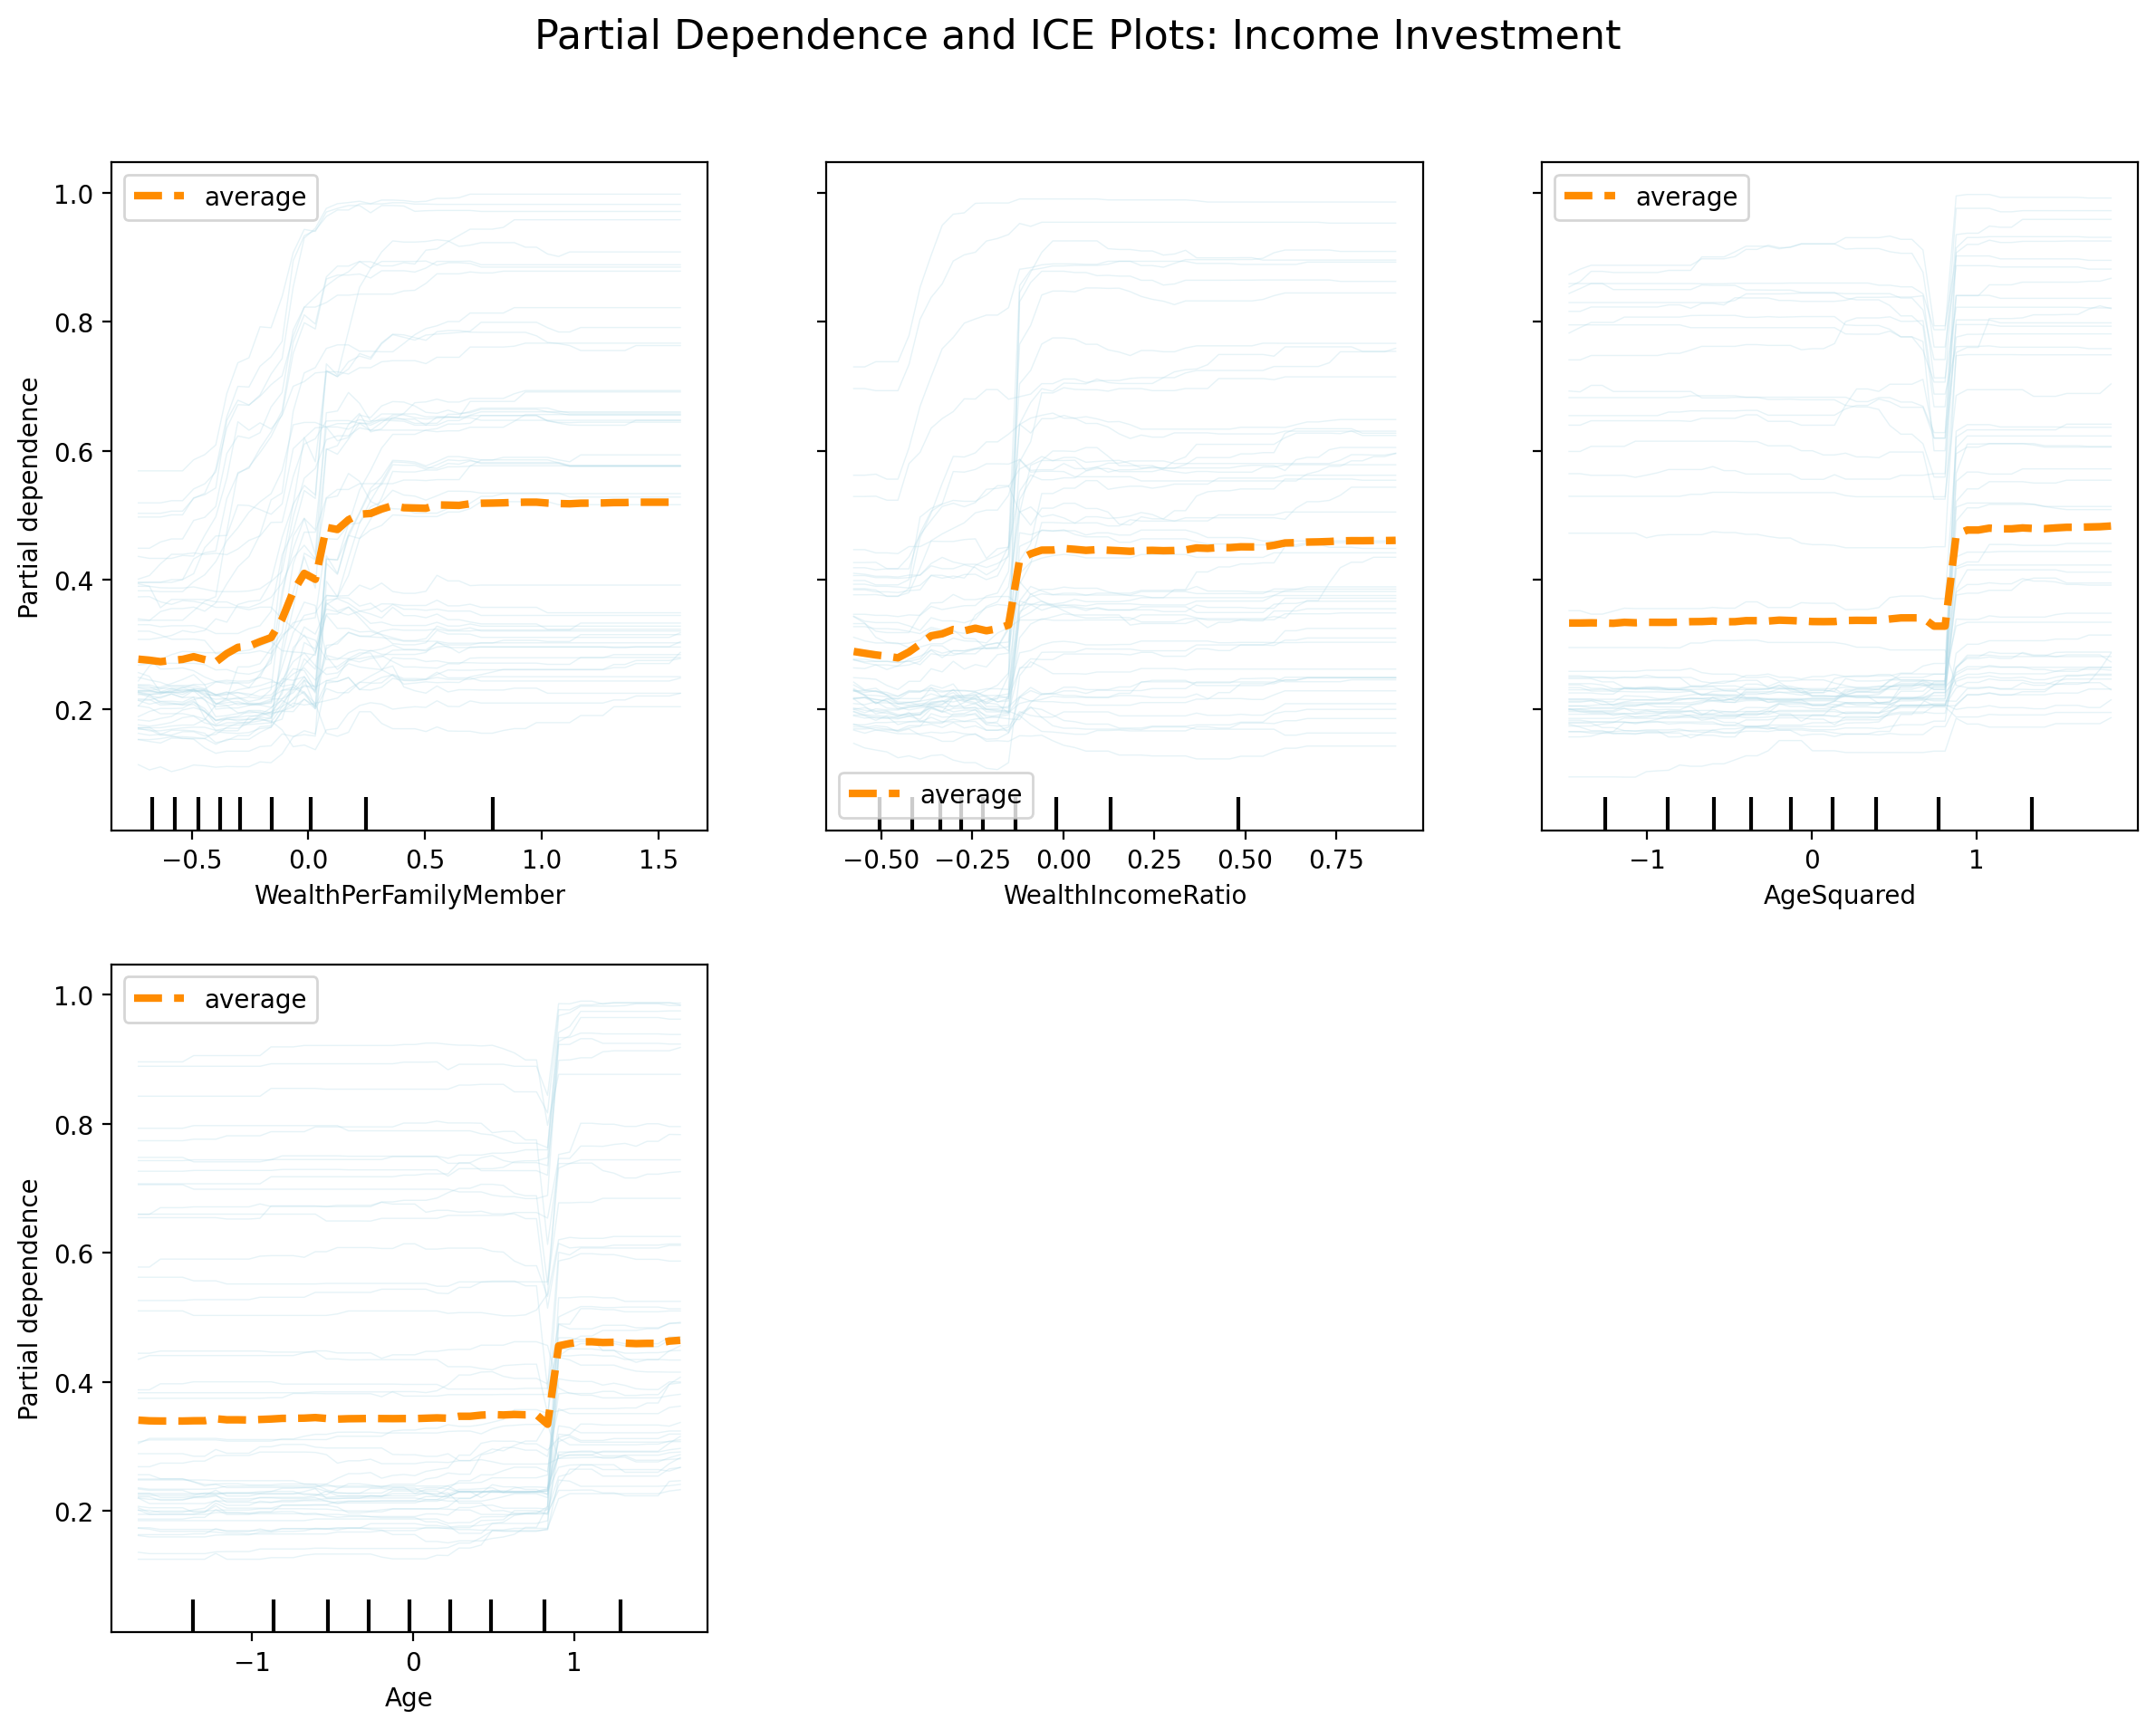

In [23]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

# 1. Selection
target_to_explain = "Income Investment"
model = best_rf_models[(target_to_explain, "Engineered")]
y_target = y_income if target_to_explain == "Income Investment" else y_accum

# 2. Get the test set
_, X_test, _, _ = split_data(final_X, y_target)

# 3. Use transformed features for PDP/ICE because engineered feature names
X_test_transformed = model[:-1].transform(X_test)
classifier = model.named_steps["classifier"]

# 4. Identify top transformed features to plot
features_to_plot = ["WealthPerFamilyMember", "WealthIncomeRatio", "AgeSquared", "Age"]

fig, ax = plt.subplots(figsize=(12, 10))

PartialDependenceDisplay.from_estimator(
    classifier,
    X_test_transformed,
    features=features_to_plot,
    kind="both",
    subsample=50,
    grid_resolution=50,
    ax=ax,
    ice_lines_kw={"color": "lightblue", "alpha": 0.3, "linewidth": 0.5},
    pd_line_kw={"color": "darkorange", "linewidth": 3},
)

plt.suptitle(f"Partial Dependence and ICE Plots: {target_to_explain}", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**PDP/ICE**:
The model uses "Cliff-Edge" logic. Financial probability doesn't grow slowly, it jumps once a client hits specific wealth and age milestones. From a business perspective, this identifies the "sweet spot" for marketing: clients just crossing the 0.05 wealth threshold or entering the 0.6 age bracket.


- **LIME**


In [24]:
import lime
from lime import lime_tabular

# 1. Setup based on your variables
target_to_explain = "Income Investment"
model = best_rf_models[(target_to_explain, "Engineered")]
y_target = y_income if target_to_explain == "Income Investment" else y_accum

# 2. Get the specific data splits
X_train, X_test, _, _ = split_data(final_X, y_target)

# 3. Initialize the LIME explainer
lime_explainer = lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=["No Need", "Need"],
    mode="classification",
)


# LIME sends numpy arrays to predict_fn; convert back to DataFrame for the pipeline
def predict_proba_for_lime(samples):
    if isinstance(samples, np.ndarray):
        samples_df = pd.DataFrame(samples, columns=X_train.columns)
    else:
        samples_df = samples
    return model.predict_proba(samples_df)


# 4. Explain a specific prediction (first client in test set)
client_index = 0
exp = lime_explainer.explain_instance(
    X_test.iloc[client_index].values, predict_proba_for_lime
)

# 5. Display explanation
exp.show_in_notebook(show_table=True)


**LIME analysis**:

As for individual SHAP, it shows that the model perceives a "willing but unable" profile; the client has the demographic and educational markers of an investor, but their current wealth levels are far below the required threshold to trigger a "Need" recommendation.
